In [1]:
from setup import *

# FFPE low pass samples

## Reading data

In [2]:
masterlist = pd.read_csv ("./Data/FFPE_lpWGS_data/known_MSI_status_lpFFPE_n265.csv")
masterlist.head(2)

,Patient_IDs,Sample_IDs,Disease,HistologySpecific,MSI_validation_method,MSI_status_by_IHC,MSIsensor_score_using_MSI-panel,Som_site_numbers_using_MSI-panel,MSI_status_by_MSI-panel,MSI_status_by_MSI-panel_or_by_IHC,Seq_material,Seq_type,Coverage,Reads_count,Access_num,Paper_link
0,UT001,UT001-A,T1 CRC,NaN,IHC,No,NaN,NaN,NaN,No,FFPE,lpWGS,0.196836,4958636,EGAS00001004219,https://doi.org/10.1101/2020.03.26.007138
1,UT001,UT001-C1,T1 CRC,NaN,IHC,No,NaN,NaN,NaN,No,FFPE,lpWGS,0.144330,3731781,EGAS00001004219,https://doi.org/10.1101/2020.03.26.007138


In [3]:
masterlist.shape

(265, 16)

In [4]:
masterlist.loc[:, ['Disease','Coverage']].groupby('Disease').median()

,Coverage
Disease,
Duodenal cancer,0.103981
T1 CRC,0.136795
UC-IBD,0.100000


In [5]:
masterlist.groupby(['MSI_status_by_MSI-panel_or_by_IHC']).count()['Sample_IDs']

MSI_status_by_MSI-panel_or_by_IHC
No     227
Yes     38
Name: Sample_IDs, dtype: int64

In [6]:
masterlist.groupby(['MSI_status_by_MSI-panel_or_by_IHC','Disease']).count()['Sample_IDs']

MSI_status_by_MSI-panel_or_by_IHC  Disease        
No                                 Duodenal cancer    88
                                   T1 CRC             62
                                   UC-IBD             77
Yes                                Duodenal cancer    32
                                   T1 CRC              2
                                   UC-IBD              4
Name: Sample_IDs, dtype: int64

In [7]:
## collected data for sWGS FFPE samples
df_f = pd.read_csv("./Data/FFPE_lpWGS_data/FFPE_sWGS_SBS_Indel_profiles_n265.csv", index_col = 0)

In [8]:
df_f.head(2)

,C2A_ACA,C2A_ACC,C2A_ACG,C2A_ACT,C2A_CCA,C2A_CCC,C2A_CCG,C2A_CCT,C2A_GCA,C2A_GCC,...,3_Del_M_2,4_Del_M_1,4_Del_M_2,4_Del_M_3,5_Del_M_1,5_Del_M_2,5_Del_M_3,5_Del_M_4,5_Del_M_5,MSI_status
UT001-A,3829,1934,445,2468,5156,2860,566,3078,2893,2238,...,123,67,32,64,86,38,57,23,119,0
UT001-C1,3450,1803,463,2131,4665,2639,669,2668,2548,1996,...,105,61,40,56,65,51,46,33,118,0


In [9]:
categorical_feats = [f for f in df_f.columns if df_f[f].dtype == 'object']

for f_ in categorical_feats:
    df_f[f_], _ = pd.factorize(df_f[f_])
    # Set feature type as categorical
    df_f[f_] = df_f[f_].astype('category')
categorical_feats

df_f.shape

(265, 180)

In [10]:
## Normalisation

df_f_norm = df_f.copy()
df_f_norm.iloc[:,:96] = df_f.iloc[:,:96].div(df_f.iloc[:,:96].sum(axis=1), axis=0).copy()
df_f_norm.iloc[:,96:179] = df_f.iloc[:,96:179].div(df_f.iloc[:,96:179].sum(axis=1), axis=0).copy()
df_f_norm.head(2)

,C2A_ACA,C2A_ACC,C2A_ACG,C2A_ACT,C2A_CCA,C2A_CCC,C2A_CCG,C2A_CCT,C2A_GCA,C2A_GCC,...,3_Del_M_2,4_Del_M_1,4_Del_M_2,4_Del_M_3,5_Del_M_1,5_Del_M_2,5_Del_M_3,5_Del_M_4,5_Del_M_5,MSI_status
UT001-A,0.017355,0.008766,0.002017,0.011186,0.023369,0.012963,0.002565,0.013951,0.013112,0.010144,...,0.003840,0.002092,0.000999,0.001998,0.002685,0.001186,0.001780,0.000718,0.003715,0
UT001-C1,0.015217,0.007952,0.002042,0.009399,0.020575,0.011640,0.002951,0.011767,0.011238,0.008804,...,0.003384,0.001966,0.001289,0.001805,0.002095,0.001644,0.001483,0.001064,0.003803,0


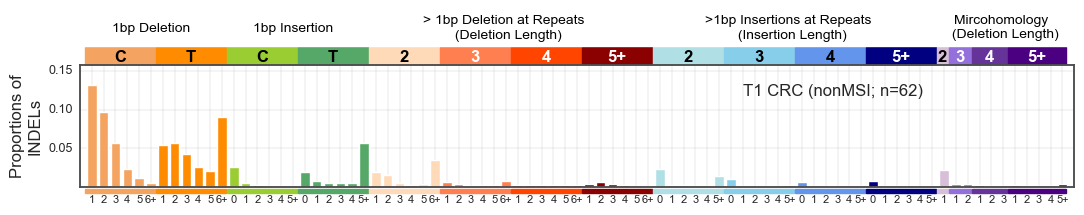

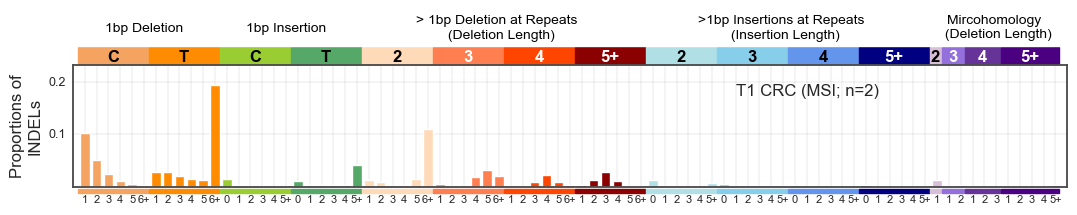

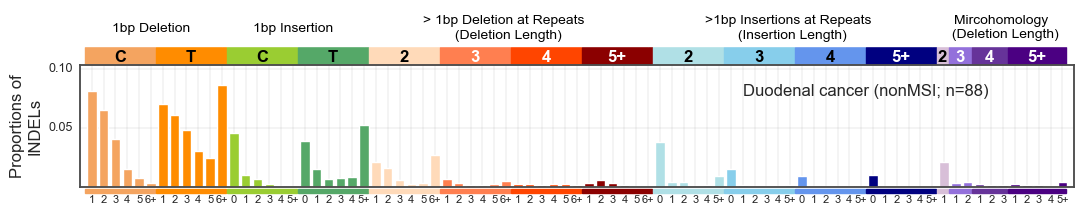

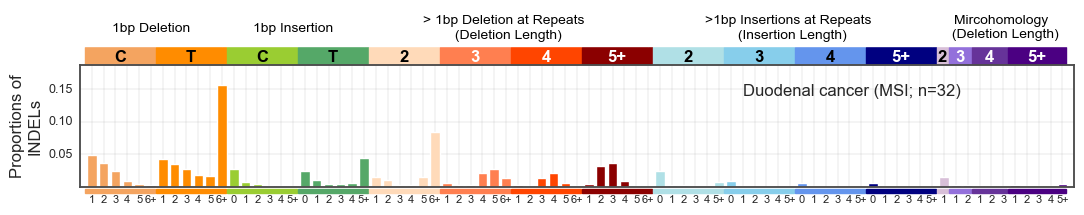

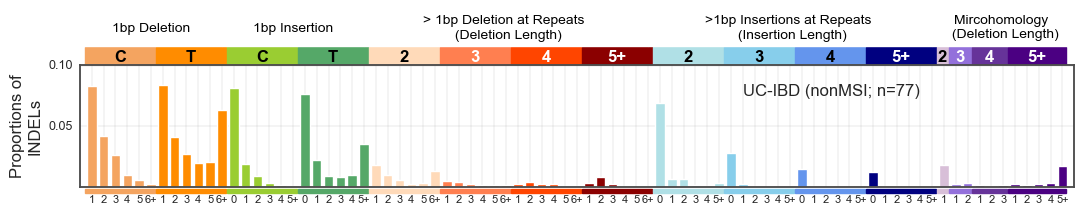

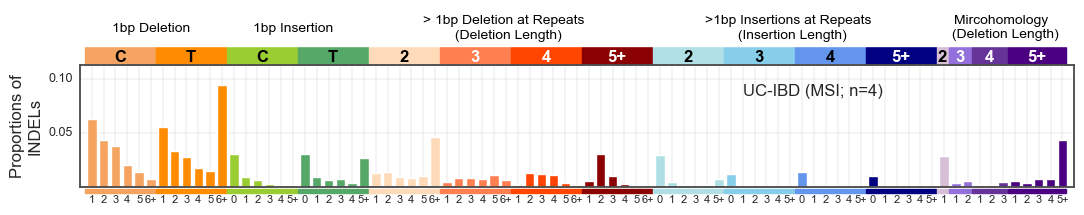

In [11]:
## Indel profiles of MSI and nonMSI samples for each FFPE cohort:

cohort_id_dict = {sid: cohort for sid, cohort in zip (masterlist['Sample_IDs'], masterlist['Disease'])}

df_f_norm['cohort'] = [cohort_id_dict.get(sid, 'None') for sid in df_f_norm.index.values]
FFPE_cohorts = df_f_norm['cohort'].unique()

n = 0
for g in FFPE_cohorts:
    df_tmp = df_f_norm.groupby("cohort").get_group(g)
    #df_f_tmp.groupby('MSI_status').get_group(0)
    n += 1
    
    sample_size = df_tmp.groupby('MSI_status').get_group(0).shape[0]
    ID83_plot(df_tmp.groupby('MSI_status').get_group(0).iloc[:,96:179].mean(), norm = True, 
              name = g + " (nonMSI; n=" + str(sample_size) + ")",
              file = "./MILO_SFig16_" + str(n) + ".pdf" )
    n += 1
    sample_size = df_tmp.groupby('MSI_status').get_group(1).shape[0]
    ID83_plot(df_tmp.groupby('MSI_status').get_group(1).iloc[:,96:179].mean(), norm = True, 
              name = g + " (MSI; n=" + str(sample_size) + ")",
             file = "./MILO_SFig16_" + str(n) + ".pdf")

## Clustering samples

In [12]:
df_f_norm_cp = df_f_norm.copy()
df_f_norm_cp['Sample_IDs'] = df_f_norm_cp.index

### Using 96-channel SBS profile

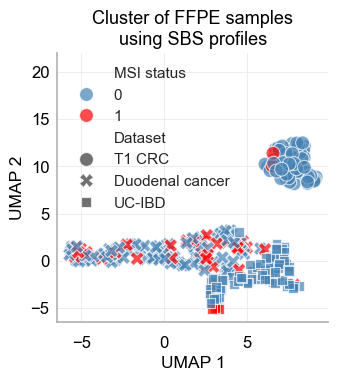

In [13]:
X = df_f_norm.iloc[:,:96].copy()

sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": 0.5 , 'grid.color': '.9', 
                                                 'ytick.major.size': 2,'axes.edgecolor': '.7'})

manifold =manifold = umap.UMAP(random_state=145, n_neighbors=15,
        min_dist= 0.5, metric='cosine').fit(X)

X_reduced = manifold.transform(X)
df_umap = pd.DataFrame (X_reduced, columns= ["UMAP 1", "UMAP 2"])
df_umap['MSI status'] = df_f_norm['MSI_status'].values
df_umap['Dataset'] = df_f_norm_cp.merge(masterlist.loc[:,["Sample_IDs", "Disease"]], on = "Sample_IDs")['Disease']

f, ax = plt.subplots(figsize = (3.5,3.5))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'MSI status', style = "Dataset", alpha = .7,
                data = df_umap, palette= {0:'steelblue',1:'red'}, s= 100, edgecolor = "w")
plt.title (f"Cluster of FFPE samples\nusing SBS profiles", fontsize = 13, color = "black")

#plt.legend(bbox_to_anchor = (0.6, 0.8),  frameon = False)
plt.legend(loc = 'upper left',  frameon = False)
plt.xlabel("UMAP 1",fontsize = 12.5, color = "black" )
plt.ylabel("UMAP 2",fontsize = 12.5, color = "black" )
plt.xticks(fontsize = 12, color = "black")
plt.yticks(fontsize = 12, color = "black")

plt.ylim (-6.5, 22)

sns.despine()
plt.savefig ("./Figures/MILO_Fig4b.pdf", bbox_inches = "tight", dpi = 300, facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

### Using 83-channel Indel mutation profile

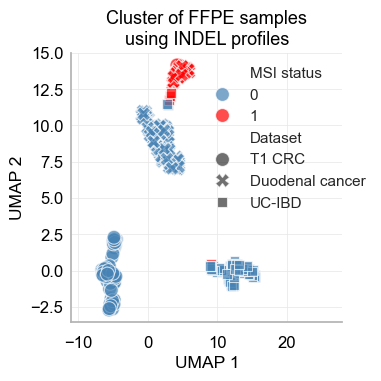

In [14]:
#pipe = make_pipeline(SimpleImputer(strategy="mean"), QuantileTransformer())

X = df_f_norm.iloc[:,96:179].copy()

manifold = umap.UMAP(random_state=145, n_neighbors=15,
        min_dist= 0.25, metric='cosine').fit(X)

X_reduced = manifold.transform(X)
df_umap = pd.DataFrame (X_reduced, columns= ["UMAP 1", "UMAP 2"])
df_umap['MSI status'] = df_f_norm['MSI_status'].values
df_umap['Dataset'] = df_f_norm_cp.merge(masterlist.loc[:,["Sample_IDs", "Disease"]], on = "Sample_IDs")['Disease']

f, ax = plt.subplots(figsize = (3.5,3.5))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'MSI status', style = "Dataset", alpha = .7,
                data = df_umap, palette= {0:'steelblue',1:'red'}, s= 100, edgecolor = "w")
plt.title (f"Cluster of FFPE samples\nusing INDEL profiles", fontsize = 13, color = "black")
plt.xlim (-11, 28)
plt.legend(bbox_to_anchor = (0.45,1),  frameon = False)
plt.xlabel("UMAP 1",fontsize = 12.5, color = "black" )
plt.ylabel("UMAP 2",fontsize = 12.5, color = "black" )
plt.xticks(fontsize = 12, color = "black")
plt.yticks(fontsize = 12, color = "black")
sns.despine()
plt.savefig ("./Figures/MILO_Fig4c.pdf", bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

## Important features

In [15]:
def get_feature_importances(x1, y1, shuffle, seed=None):
    
    # Shuffle target if required
    if shuffle:
        y1 = pd.Series(y1).sample(frac=1.0).values
    
    rf = RandomForestClassifier()
    
    rf = rf.fit(x1, y1)

    # Get feature importances
    imp_df = pd.DataFrame()
    imp_df["feature"] = list(rf.feature_names_in_)
    imp_df["importance"] = rf.feature_importances_
    
    return imp_df

In [16]:
def feats_score_null_importance (actual_imp_df_tmp, null_imp_df, perc = 0.95):
    feature_scores = []
    for _f in actual_imp_df_tmp['feature'].unique():
        f_null_imps = null_imp_df.loc[null_imp_df['feature'] == _f, 'importance'].values
        f_act_imps = actual_imp_df.loc[actual_imp_df_tmp['feature'] == _f, 'importance'].mean()
        gain_score = np.log(1e-10 + f_act_imps / (1e-10 + np.percentile(f_null_imps, perc)))  # Avoid didvide by zero
        feature_scores.append(gain_score)
    return (actual_imp_df_tmp['feature'].unique(), feature_scores)

### Null importance

In [17]:
x = df_f_norm.drop(["MSI_status", "cohort"], axis = 1).iloc[:, 96:].copy()
feature = x.columns.values

## convert targeted variable as integer variables
#from sklearn.preprocessing import LabelEncoder, StandardScaler
encoder = LabelEncoder()
encoder.fit(df_f_norm['MSI_status'])
y = encoder.transform(df_f_norm['MSI_status'])

In [18]:
nb_runs = 50

null_imp_df_FFPE = pd.DataFrame()

for i in range(nb_runs):
    # Get current run importances
    np.random.seed (nb_runs+1)
    imp_df = get_feature_importances(x1 = x, y1 = y, shuffle=True)
    imp_df['run'] = i + 1 
    # Concat the latest importances with the old ones
    null_imp_df_FFPE = pd.concat([null_imp_df_FFPE, imp_df], axis=0)
    
print('Done')

Done


In [19]:
null_imp_df_FFPE.head(2)

,feature,importance,run
0,1_Del_C_0,0.015190,1
1,1_Del_C_1,0.015819,1


### Feature score

Comparing actual feature importante (without shuffling) to null importance distribution to derive feature score.

In [20]:
split_num = 5
remained_fs = feature

all_features = []
all_scores = []
n_repeat = 20
trail_id = []

for i in range(n_repeat):
    np.random.seed(i)
    trail_id += ['run' + str(i)] * len(remained_fs) * 5
    kfold = StratifiedKFold(n_splits = split_num, shuffle=True)
    for train_index, test_index in kfold.split(x, y):

        x_train, x_test = x.iloc[train_index,:][remained_fs], x.iloc[test_index,:][remained_fs]
        y_train, y_test = y[train_index], y[test_index]
        
        ## Actual feature importance
        actual_imp_df = get_feature_importances(x1 = x_train, y1 = y_train, shuffle = False)
        
        ## getting feature score
        feats, scores= feats_score_null_importance (actual_imp_df, null_imp_df_FFPE)
        
        ## recording data
        all_features += list(feats)
        all_scores += list(scores)

In [21]:
scores_df_FFPE = pd.DataFrame({"features": all_features, "scores": all_scores})
sorted_features_FFPE = scores_df_FFPE.groupby("features").mean().sort_values("scores", ascending = False).index.values
scores_df_FFPE.head(2)

,features,scores
0,1_Del_C_0,1.393386
1,1_Del_C_1,-1.114033


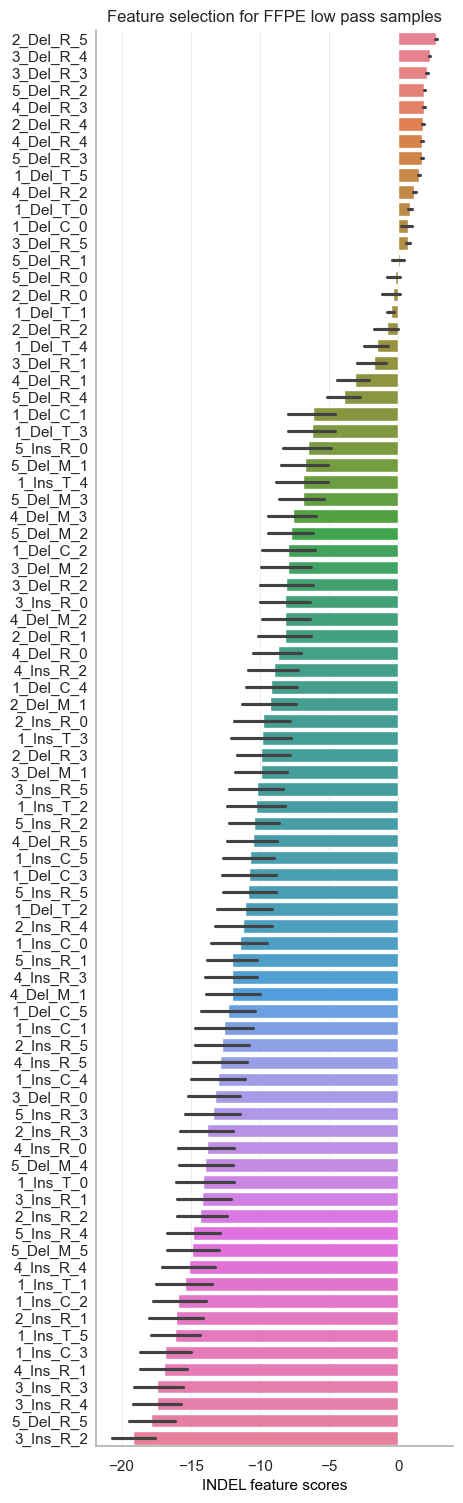

In [22]:
f, ax = plt.subplots(figsize=(5, 15))
sns.barplot(x='scores', y='features', data=scores_df_FFPE, order = sorted_features_FFPE, palette = "husl")
sns.despine()
plt.tight_layout()
plt.ylabel("")
plt.title("Feature selection for FFPE low pass samples")
plt.xlabel("INDEL feature scores", fontsize = 11, color = "black")
plt.savefig ("./Figures/MILO_SFig19a.pdf", bbox_inches = "tight", dpi = 300, facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

### Selecting the top 10 key features

In [23]:
## top 10 features with highest feature score
selected_features_FFPE = sorted_features_FFPE[:10]
selected_features_FFPE

array(['2_Del_R_5', '3_Del_R_4', '3_Del_R_3', '5_Del_R_2', '4_Del_R_3',
       '2_Del_R_4', '4_Del_R_4', '5_Del_R_3', '1_Del_T_5', '4_Del_R_2'],
      dtype=object)

In [24]:
SBS_ID_channels_new = []
for a in SBS_ID_channels:
    b = a.replace('>', "2")
    c = b.replace('@', '_')
    d = c.replace (':', '_')
    SBS_ID_channels_new.append (d)

In [25]:
feats_imp_FFPE = (scores_df_FFPE.groupby("features").describe()['scores']).loc[selected_features_FFPE,'mean'].to_dict()
feats_vec_FFPE = pd.Series({f: 0.0 for f in SBS_ID_channels_new})
for f in feats_imp_FFPE.keys():
    feats_vec_FFPE[f] = feats_imp_FFPE.get (f)
    
FFPE_selected_features = feats_vec_FFPE[96:].values

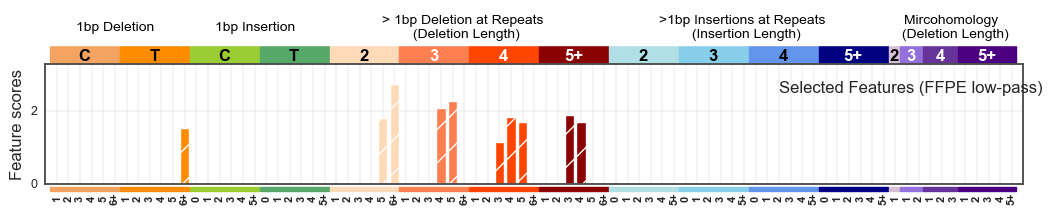

In [26]:
ID83_features_plot(FFPE_selected_features, name = "Selected Features (FFPE low-pass)")

## Reclustering using important features

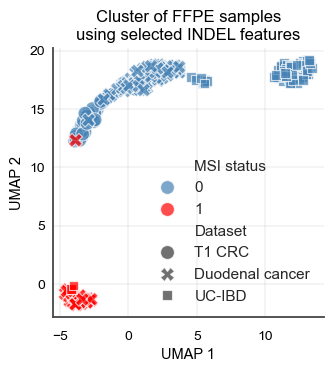

In [27]:
X = df_f_norm_cp.loc[:,selected_features_FFPE].copy()
# Fit UMAP to processed data
manifold = umap.UMAP(random_state = 13, n_neighbors = 40,
        min_dist= 0.2, metric = 'cosine').fit(X)

X_reduced = manifold.transform(X)

df_umap = pd.DataFrame (X_reduced, columns= ["UMAP 1", "UMAP 2"])
df_umap['MSI status'] = df_f_norm['MSI_status'].values
df_umap['Dataset'] = df_f_norm_cp.merge(masterlist.loc[:,["Sample_IDs", "Disease"]], on = "Sample_IDs")['Disease']
f, ax = plt.subplots(figsize = (3.5,3.5))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'MSI status', style = "Dataset", alpha = .7,
                data = df_umap, palette= {0:'steelblue',1:'red'}, s= 100, edgecolor = "w")
plt.title (f"Cluster of FFPE samples\nusing selected INDEL features",fontsize = 12, color = "black")

plt.legend("", frameon = False)
plt.xlabel("UMAP 1",fontsize = 10.5, color = "black" )
plt.ylabel("UMAP 2",fontsize = 10.5, color = "black" )
plt.xticks(fontsize = 10, color = "black")
plt.yticks(fontsize = 10, color = "black")
plt.legend(frameon = False)
sns.despine()
#plt.xlim(-20,15)
plt.savefig ("./Figures/MILO_SFig20a.pdf", bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

# Fresh frozen samples (low-pass)

## Read data

In [28]:
ff_lowpass_df = pd.read_csv("./Data/FF_lpWGS_data/EPICC/FF_lowpass_matrix.csv", index_col= 0)
ff_lowpass_df.head(2)

,C2A_ACA,C2A_ACC,C2A_ACG,C2A_ACT,C2A_CCA,C2A_CCC,C2A_CCG,C2A_CCT,C2A_GCA,C2A_GCC,...,4_Del_M_1,4_Del_M_2,4_Del_M_3,5_Del_M_1,5_Del_M_2,5_Del_M_3,5_Del_M_4,5_Del_M_5,MSI_status,data_source
C516_B1_G5_L1,2217.0,1404.0,327.0,1521.0,5954.0,3381.0,625.0,4258.0,2158.0,1932.0,...,206.0,98.0,307.0,412.0,177.0,189.0,216.0,930.0,1.0,EPICC_lpWGS
C516_C1_G6_L1,1094.0,694.0,131.0,716.0,2332.0,1635.0,324.0,1910.0,1068.0,880.0,...,110.0,64.0,148.0,145.0,71.0,87.0,102.0,251.0,1.0,EPICC_lpWGS


In [29]:
ff_lowpass_df.loc[["C519_B2_L1_L1"], :].iloc[:,96:179].T.to_csv ("./Data/test_noise.csv", 
                                                                 index = False)

In [30]:
ff_lowpass_df.groupby(['data_source','MSI_status']).count()

C2A_ACA  C2A_ACC  C2A_ACG  C2A_ACT  C2A_CCA   
data_source   MSI_status                                                
EPICC_lpWGS   0.0             226      226      226      226      226  \
              1.0              41       41       41       41       41   
Gland_lpWGS   0.0             148      148      148      148      148   
              1.0             101      101      101      101      101   
Mseq_ds_lpWGS 0.0              39       39       39       39       39   
              1.0              13       13       13       13       13   

                          C2A_CCC  C2A_CCG  C2A_CCT  C2A_GCA  C2A_GCC  ...   
data_source   MSI_status                                               ...   
EPICC_lpWGS   0.0             226      226      226      226      226  ...  \
              1.0              41       41       41       41       41  ...   
Gland_lpWGS   0.0             148      148      148      148      148  ...   
              1.0             101      101      101      101      101  ...   
Mseq_ds_lpWGS 0.0              39       39       39       39       39  ...   
              1.0              13       13       13       13       13  ...   

                          3_Del_M_1  3_Del_M_2  4_Del_M_1  4_Del_M_2   
data_source   MSI_status                                               
EPICC_lpWGS   0.0               226        226        226        226  \
              1.0                41         41         41         41   
Gland_lpWGS   0.0               148        148        148        148   
              1.0               101        101        101        101   
Mseq_ds_lpWGS 0.0                39         39         39         39   
              1.0                13         13         13         13   

                          4_Del_M_3  5_Del_M_1  5_Del_M_2  5_Del_M_3   
data_source   MSI_status                                               
EPICC_lpWGS   0.0               226        226        226        226  \
              1.0                41         41         41         41   
Gland_lpWGS   0.0               148        148        148        148   
              1.0               101        101        101        101   
Mseq_ds_lpWGS 0.0                39         39         39         39   
              1.0                13         13         13         13   

                          5_Del_M_4  5_Del_M_5  
data_source   MSI_status                        
EPICC_lpWGS   0.0               226        226  
              1.0                41         41  
Gland_lpWGS   0.0               148        148  
              1.0               101        101  
Mseq_ds_lpWGS 0.0                39         39  
              1.0                13         13  

[6 rows x 179 columns]

In [31]:
## normalisation

ff_lowpass_df_norm = ff_lowpass_df.copy()
ff_lowpass_df_norm.iloc[:,:96] = ff_lowpass_df.iloc[:,:96].div(ff_lowpass_df.iloc[:,:96].sum(axis=1), axis=0)
ff_lowpass_df_norm.iloc[:,96:179] = ff_lowpass_df.iloc[:,96:179].div(ff_lowpass_df.iloc[:,96:179].sum(axis=1), axis=0)

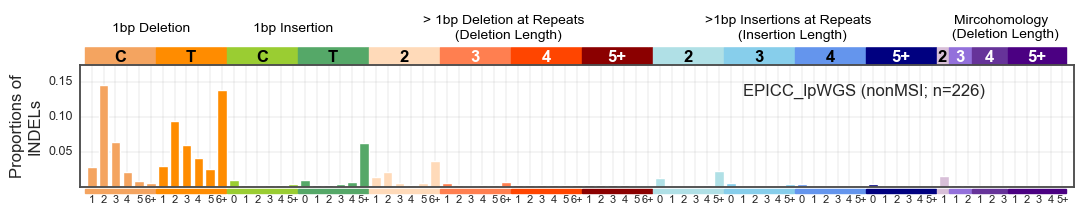

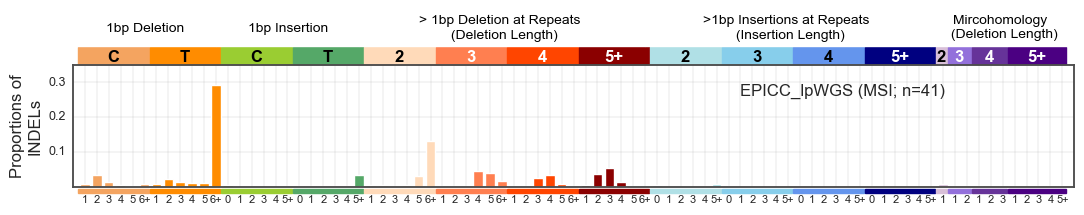

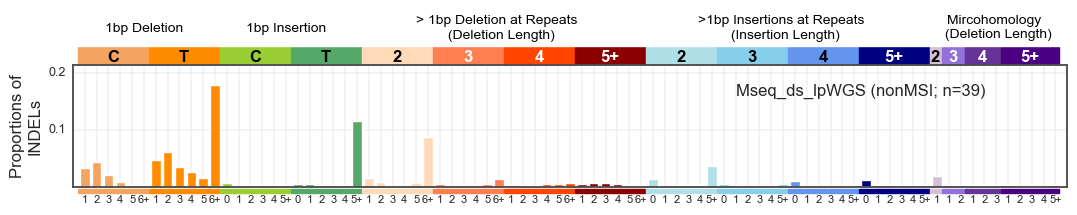

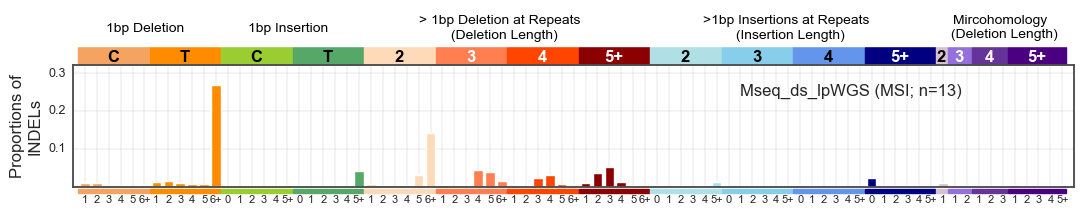

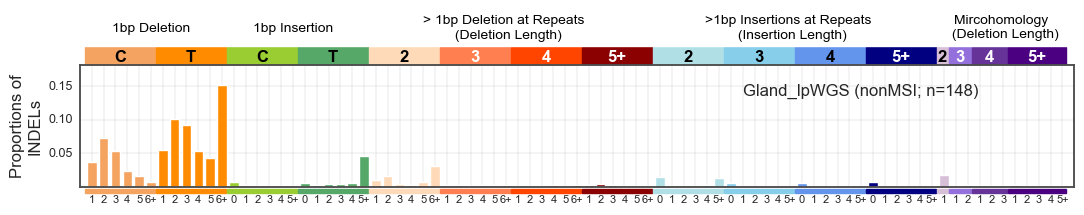

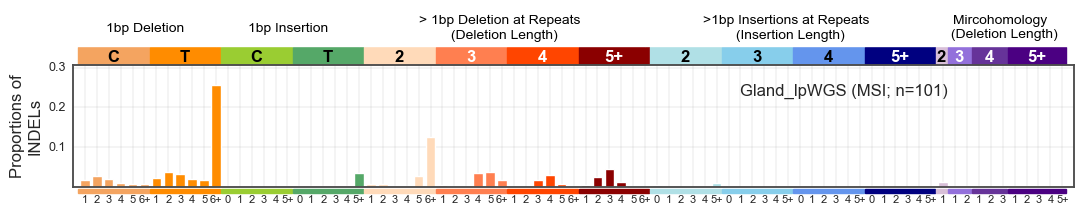

In [32]:
FF_cohorts = ff_lowpass_df_norm['data_source'].unique()
n = 0
for g in FF_cohorts:
    df_tmp = ff_lowpass_df_norm.groupby("data_source").get_group(g)
    n += 1
    
    sample_size = df_tmp.groupby('MSI_status').get_group(0).shape[0]
    ID83_plot(df_tmp.groupby('MSI_status').get_group(0).iloc[:,96:179].mean(), norm = True, 
              name = g + " (nonMSI; n=" + str(sample_size) + ")",
              file = "./MILO_SFig17c_" + str(n) + ".pdf" )
    #n += 1
    sample_size = df_tmp.groupby('MSI_status').get_group(1).shape[0]
    ID83_plot(df_tmp.groupby('MSI_status').get_group(1).iloc[:,96:179].mean(), norm = True, 
              name = g + " (MSI; n=" + str(sample_size) + ")",
             file = "./MILO_SFig17d_" + str(n) + ".pdf")

## Clustering samples

### Using 96-channel SBS mutation profile

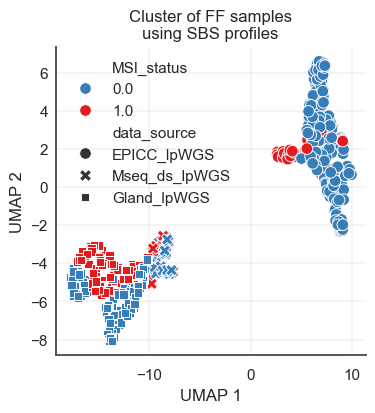

In [33]:
X = ff_lowpass_df_norm.iloc[:,:96].copy()

manifold = umap.UMAP(random_state=1345, n_neighbors = 45,
        min_dist= 0.4, metric = "cosine").fit(X)

X_reduced = manifold.transform(X)

df_umap = pd.DataFrame (X_reduced, columns= ["UMAP 1", "UMAP 2"])

#df_umap['MultiGroup_status'] = real_epicc_lowpass_samples_T['MultiGroup_status'].values
df_umap['MSI_status'] = ff_lowpass_df['MSI_status'].values
df_umap['data_source'] = ff_lowpass_df['data_source'].values

f, ax = plt.subplots(figsize = (4,4))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'MSI_status', style = "data_source", s = 70,
                palette= {0:sns.color_palette("Set1")[1], 1:sns.color_palette("Set1")[0]},
                data = df_umap)
plt.title (f"Cluster of FF samples\nusing SBS profiles")

plt.legend(loc = 'upper left', frameon = False)
#plt.xlim (-10, 24)
sns.despine()
plt.savefig ("./Figures/MILO_SFig16a.pdf", bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

### Using 83-channel Indel mutation profile

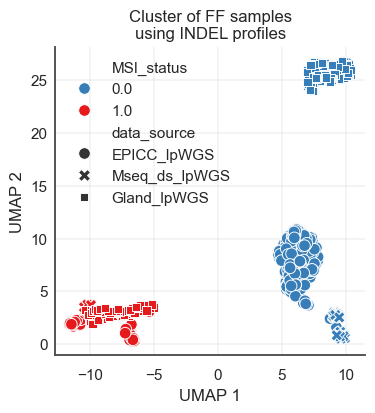

In [34]:
X = ff_lowpass_df_norm.iloc[:,96:179].copy()

manifold = umap.UMAP(random_state=145, n_neighbors=50,
        min_dist= 0.3, metric = "cosine").fit(X)

X_reduced = manifold.transform(X)

df_umap = pd.DataFrame (X_reduced, columns= ["UMAP 1", "UMAP 2"])

#df_umap['MultiGroup_status'] = real_epicc_lowpass_samples_T['MultiGroup_status'].values
df_umap['MSI_status'] = ff_lowpass_df['MSI_status'].values
df_umap['data_source'] = ff_lowpass_df['data_source'].values

f, ax = plt.subplots(figsize = (4,4))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'MSI_status', style = "data_source", s = 70,
                palette= {0:sns.color_palette("Set1")[1], 1:sns.color_palette("Set1")[0]},
                data = df_umap,)

plt.title (f"Cluster of FF samples\nusing INDEL profiles")

plt.legend(frameon = False)

sns.despine()
plt.savefig ("./Figures/MILO_SFig16b.pdf", bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

## Important features

### Null importance

In [35]:
x = ff_lowpass_df_norm.iloc[:,96:179].copy()
y = encoder.transform(ff_lowpass_df_norm['MSI_status'])

start = time.time()
nb_runs = 50

null_imp_df_FF = pd.DataFrame()

for i in range(nb_runs):
    # Get current run importances
    np.random.seed(i)
    imp_df = get_feature_importances(x1 = x, y1 = y, shuffle = True)
    imp_df['run'] = i + 1 
    # Concat the latest importances with the old ones
    null_imp_df_FF = pd.concat([null_imp_df_FF, imp_df], axis = 0)
    # Display current run and time used
    spent = (time.time() - start) / 60
print("Done")

Done


In [36]:
null_imp_df_FF.head(2)

,feature,importance,run
0,1_Del_C_0,0.013287,1
1,1_Del_C_1,0.012776,1


### Feature score

In [37]:
split_num = 5

remained_fs = feature

all_features = []
all_scores = []
n_repeat = 20

trail_id = []

for i in range(n_repeat):
    np.random.seed(i + 123)
    trail_id += ['run' + str(i)] * len(remained_fs) * 5
    kfold = StratifiedKFold(n_splits = split_num, shuffle=True)
    for train_index, test_index in kfold.split(x, y):

        x_train, x_test = x.iloc[train_index,:][remained_fs], x.iloc[test_index,:][remained_fs]
        y_train, y_test = y[train_index], y[test_index]
            
        actual_imp_df = get_feature_importances(x1 = x_train, y1 = y_train, shuffle=False)
        feats, scores= feats_score_null_importance (actual_imp_df, null_imp_df_FF)
        all_features += list(feats)
        all_scores += list(scores)

In [38]:
scores_df_FF = pd.DataFrame({"features": all_features, "scores": all_scores})
sorted_features_FF = scores_df_FF.groupby("features").mean().sort_values("scores", ascending = False).index.values
scores_df_FF.head(2)

,features,scores
0,1_Del_C_0,0.838813
1,1_Del_C_1,-2.912654


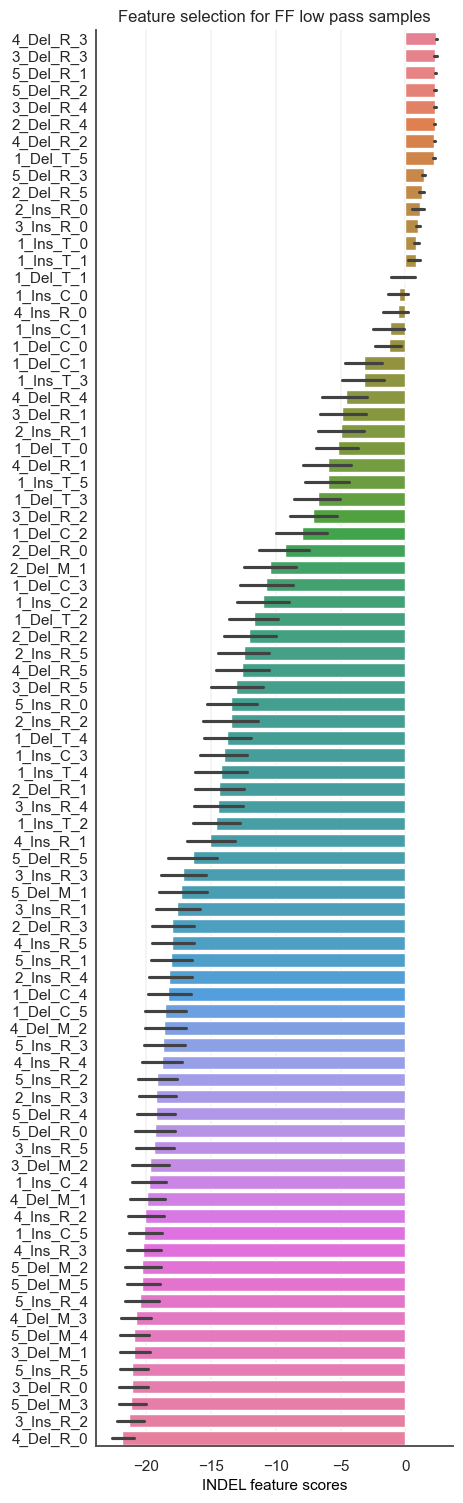

In [39]:
f, ax = plt.subplots(figsize=(5, 15))

sns.barplot(x='scores', y='features', data=scores_df_FF, order = sorted_features_FF, palette = "husl")
sns.despine()
#ax.set_title('INDEL Feature scores', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.ylabel("")
plt.title("Feature selection for FF low pass samples")
plt.xlabel("INDEL feature scores", fontsize = 11, color = "black")
plt.savefig ("./Figures/MILO_SFig19b.pdf", bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

### Selecting key features

In [40]:
## take the top 10 important features
selected_features_FF = sorted_features_FF[:10]

In [41]:
feats_imp_FF = (scores_df_FF.groupby("features").describe()['scores']).loc[selected_features_FF,'mean'].to_dict()
feats_vec_FF = pd.Series({f: 0.0 for f in SBS_ID_channels_new}) 
for f in feats_imp_FF.keys():
    feats_vec_FF[f] = feats_imp_FF.get (f)
    
FF_selected_features = feats_vec_FF[96:].values

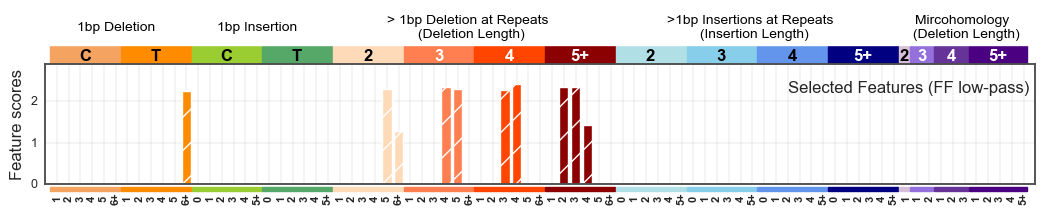

In [42]:
ID83_features_plot(FF_selected_features, name = "Selected Features (FF low-pass)")

## Reclustering using important features

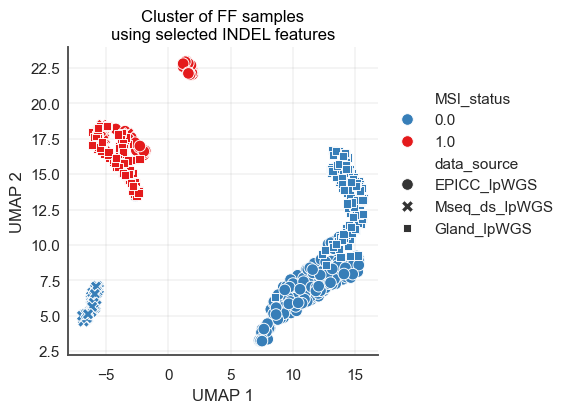

In [43]:
X = ff_lowpass_df_norm.loc[:, selected_features_FF].copy()

# Fit UMAP to processed data

manifold = umap.UMAP(random_state=145, n_neighbors=30,
        min_dist= 0.4, metric = 'cosine').fit(X)

X_reduced = manifold.transform(X)

df_umap = pd.DataFrame (X_reduced, columns= ["UMAP 1", "UMAP 2"])

#df_umap['MultiGroup_status'] = real_epicc_lowpass_samples_T['MultiGroup_status'].values
df_umap['MSI_status'] = ff_lowpass_df['MSI_status'].values
df_umap['data_source'] = ff_lowpass_df['data_source'].values

f, ax = plt.subplots(figsize = (4,4))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'MSI_status', style = "data_source", s = 70,
                palette= {0:sns.color_palette("Set1")[1], 1:sns.color_palette("Set1")[0]},
                data = df_umap,)

plt.title (f"Cluster of FF samples\nusing selected INDEL features", fontsize = 12, color = "black")

plt.legend(bbox_to_anchor = (1, 0.9), frameon = False)

sns.despine()
plt.savefig ("./Figures/MILO_SFig20b.pdf", bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

# Comparing data between FFPE and FF data cohorts

## MSI Indel profiles

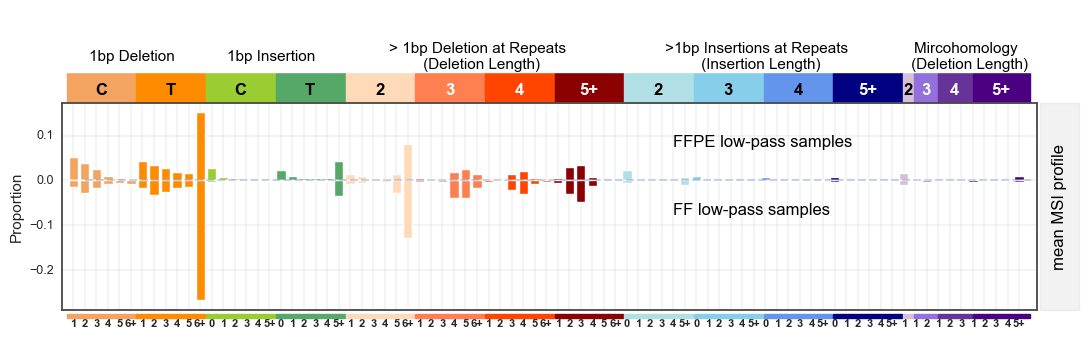

In [44]:
MSI_FF = ff_lowpass_df_norm.loc [ff_lowpass_df_norm["MSI_status"] == 1, :].iloc[:,96:179].mean()
MSI_FFPE = df_f_norm.drop ("cohort", axis = 1).groupby("MSI_status").mean().iloc[1,:][96:179]
ID83_compare_profile(MSI_FFPE, MSI_FF, 
                     name1 = 'FFPE low-pass samples', 
                     name2 = 'FF low-pass samples', 
                     label = 'mean MSI profile', file = "./Figures/MILO_Fig4e.pdf")

## Non-MSI Indel Profiles

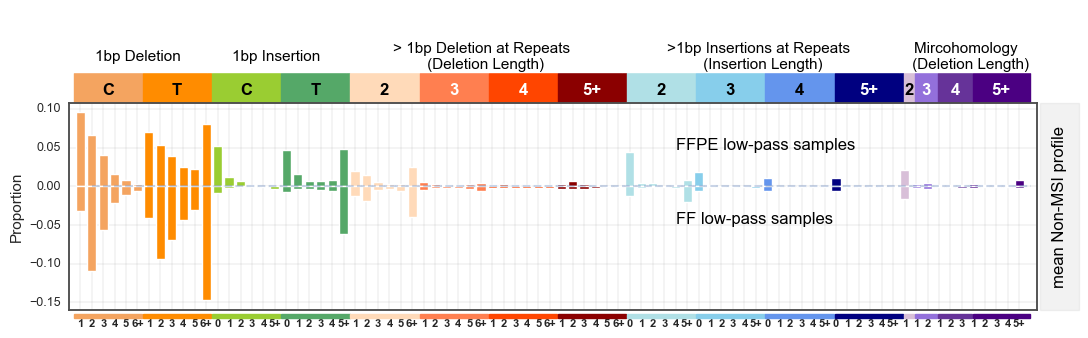

In [45]:
non_MSI_FF = ff_lowpass_df_norm.loc [ff_lowpass_df_norm["MSI_status"] == 0, :].iloc[:,96:179].mean()
non_MSI_FFPE = df_f_norm.drop ("cohort", axis = 1).loc [df_f_norm["MSI_status"] == 0, :].iloc[:,96:179].mean()
ID83_compare_profile(non_MSI_FFPE, non_MSI_FF, 
                     name1 = 'FFPE low-pass samples', 
                     name2 = 'FF low-pass samples', 
                     label = 'mean Non-MSI profile', file = "./Figures/MILO_Fig4d.pdf")

## Important fetaures

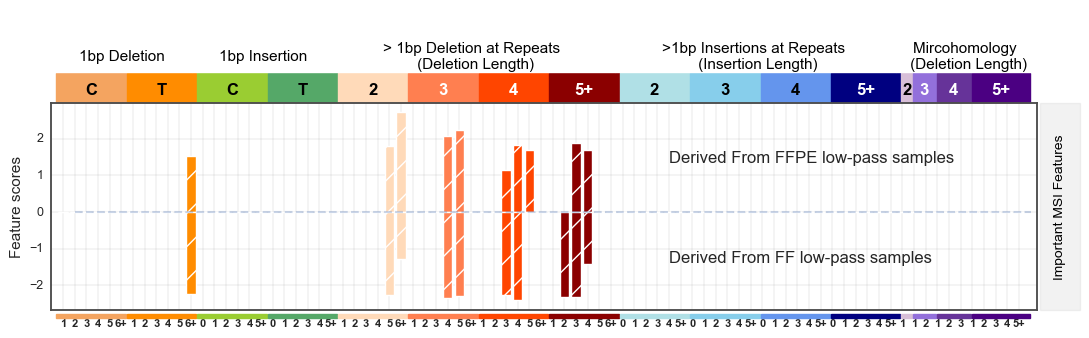

In [46]:
ID83_features_plot2(FFPE_selected_features, FF_selected_features, label = "Important MSI Features", 
                    file = "./Figures/MILO_Fig4f.pdf")

# Low purity Samples

In our discoverty cohort, we used EPICC samples that were included in the original paper. Here we used an expanded set of EPICC low pass samples and some of them were excluded in the original paper due to low-purity issue or others.

In [47]:
epicc_lowpass_df_t = pd.read_csv ("./Data/EPICC_all_low_pass_data.csv", index_col= 0)
epicc_lowpass_df_t.head(2)

,C2A_ACA,C2A_ACC,C2A_ACG,C2A_ACT,C2A_CCA,C2A_CCC,C2A_CCG,C2A_CCT,C2A_GCA,C2A_GCC,...,5_Del_M_1,5_Del_M_2,5_Del_M_3,5_Del_M_4,5_Del_M_5,sample_barcode,estimated_purity,MSI_status,Coverage,Included_in_Original_EPICC_papers
samples,,,,,,,,,,,,,,,,,,,,,
C516_A1_G3_L1,3264.0,2121.0,478.0,2159.0,9585.0,4440.0,798.0,4706.0,3612.0,3019.0,...,312.0,151.0,195.0,174.0,707.0,EPICC_C516_A1_G3_L1,0.236236,1,1.9952,N
C516_B1_G5_L1,2217.0,1404.0,327.0,1521.0,5954.0,3381.0,625.0,4258.0,2158.0,1932.0,...,412.0,177.0,189.0,216.0,930.0,EPICC_C516_B1_G5_L1,0.685686,1,0.9570,Y


In [48]:
epicc_lowpass_df_t.groupby("MSI_status").count()

,C2A_ACA,C2A_ACC,C2A_ACG,C2A_ACT,C2A_CCA,C2A_CCC,C2A_CCG,C2A_CCT,C2A_GCA,C2A_GCC,...,4_Del_M_3,5_Del_M_1,5_Del_M_2,5_Del_M_3,5_Del_M_4,5_Del_M_5,sample_barcode,estimated_purity,Coverage,Included_in_Original_EPICC_papers
MSI_status,,,,,,,,,,,,,,,,,,,,,
0,386,386,386,386,386,386,386,386,386,386,...,386,386,386,386,386,386,386,386,386,386
1,88,88,88,88,88,88,88,88,88,88,...,88,88,88,88,88,88,88,88,88,88


In [49]:
epicc_lowpass_df_t_norm = epicc_lowpass_df_t.copy()
epicc_lowpass_df_t_norm.iloc[:,:96] = epicc_lowpass_df_t.iloc[:,:96].div(epicc_lowpass_df_t.iloc[:,:96].sum(axis=1), axis=0).copy()
epicc_lowpass_df_t_norm.iloc[:,96:179] = epicc_lowpass_df_t.iloc[:,96:179].div(epicc_lowpass_df_t.iloc[:,96:179].sum(axis=1), axis=0).copy()

## Clustering all epicc MMRd lowpass samples

In [50]:
epicc_lowpass_df_t_norm_msi = epicc_lowpass_df_t_norm.loc[epicc_lowpass_df_t_norm['MSI_status'] == 1,:].copy()

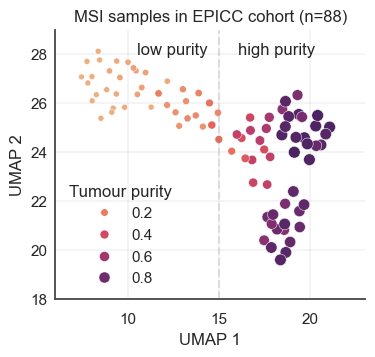

In [51]:
X = epicc_lowpass_df_t_norm_msi.iloc[:,96:179].to_numpy()

# Fit UMAP to processed data
manifold = umap.UMAP(random_state = 170, min_dist = 0.8, n_neighbors = 70).fit(X)

X_reduced = manifold.transform(X)

df_umap = pd.DataFrame (X_reduced, columns= ["UMAP 1", "UMAP 2"])

df_umap['sample_barcode'] = epicc_lowpass_df_t_norm_msi['sample_barcode'].values
df_umap['estimated_purity'] = epicc_lowpass_df_t_norm_msi['estimated_purity'].values

f, ax = plt.subplots(figsize = (4,3.5))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", size = 'estimated_purity', 
                hue = 'estimated_purity', palette= 'flare',
                data = df_umap,)
plt.title (f"MSI samples in EPICC cohort (n=88)")
sns.despine()
plt.xlim (6, 23)
plt.ylim (18, 29)
plt.axvline(15, linestyle = "--", color = "grey", alpha = 0.2)
plt.annotate("low purity",(10.5,28))
plt.annotate("high purity",(16,28))
plt.legend(title = "Tumour purity", loc = "lower left", frameon = False)
plt.savefig ("./Figures/MILO_Fig5a.pdf", bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
plt.show()

In [52]:
print (df_umap.loc[df_umap['UMAP 1'].values < 15, 'estimated_purity'].median())
print (df_umap.loc[df_umap['UMAP 1'].values >= 15, 'estimated_purity'].median())

0.051051051051051
0.8158158158158159


In [53]:
sum(df_umap['UMAP 1'].values < 15), sum(df_umap['UMAP 1'].values >= 15)

(39, 49)

## High-purity MMRd samples

In [54]:
def ID83_plot(sig, name = "", norm = False, xticks_label = False, width = 11, height = 2.7, 
              bar_width = 0.8, grid = 0.2, label = "", file = ""):
    
    channel = 83; col_list = []
    
    ## Setting up colors:
    color_names1 = ['sandybrown', 'darkorange','yellowgreen','g','peachpuff','coral','orangered',
                    'darkred', 'powderblue', 'skyblue','cornflowerblue','navy']
    for col in color_names1:
        col_list += [col] * 6

    col_list = col_list + ['thistle'] + ['mediumpurple'] * 2 + ['rebeccapurple'] * 3 + ['indigo'] *5
    
    col_set = color_names1 + ['thistle','mediumpurple','rebeccapurple','indigo']

    ## The top layer annotations:
    top_label = ['1bp Deletion', '1bp Insertion', '> 1bp Deletion at Repeats \n (Deletion Length)', 
             '>1bp Insertions at Repeats \n (Insertion Length)', 'Mircohomology \n (Deletion Length)']
    second_top_layer = ['C', 'T', 'C','T','2','3','4','5+','2','3','4','5+','2','3','4','5+']
    second_top_layer_color = ["black"] * 5 + ["white"] * 3 + ["black"] * 3 + ["white", "black"] + ["white"] * 3
    ## The bottom layer annotations:
    xlabel = ['1','2','3','4','5','6+','1','2','3','4','5','6+','0','1','2','3','4','5+','0','1','2','3','4','5+',
         '1','2','3','4','5','6+','1','2','3','4','5','6+','1','2','3','4','5','6+','1','2','3','4','5','6+',
         '0','1','2','3','4','5+','0','1','2','3','4','5+','0','1','2','3','4','5+','0','1','2','3','4','5+',
         '1','1','2','1','2','3','1','2','3','4','5+']
    bottom_layer = ['Homopolymer Length', 'Homopolymer Length', 'Number of Repeat Units',  'Number of Repeat Units',
                'Microhomology Length']

    ## figuer configuration setting
    sns.set(rc={"figure.figsize":(width, height)})
    sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": grid, 'grid.color': '.7', 'ytick.major.size': 2,
                                                'axes.edgecolor': '.3', 'axes.linewidth': 1.35,})
    ## Plot the normalized version 
    if norm:
        normed_sig = sig / np.sum(sig)
        plt.bar(range(channel),normed_sig , width = bar_width, color =col_list)
        plt.ylim (np.min(normed_sig)*1.05, np.max(normed_sig) * 1.2) ##
        
        plt.ylabel("Proportions of\nINDELs")        
        plt.annotate (name, (55, np.max(normed_sig) * 0.8))

    ## plot the original version:
    else:
        plt.bar(range(channel), sig , width = bar_width, color =col_list)
        plt.xticks(rotation=90, size = 7, weight='bold')
        plt.ylim (np.min(sig)*1.05, np.max(sig)*1.2) #3
        plt.annotate (name, (55, np.max(sig) *0.8))
        plt.annotate ('Total =' + format(np.sum(np.abs(sig)), ','), (0, np.max(sig)*1.01))
        plt.ylabel("Counts", size = 12)
    
    plt.xticks(range(channel), xlabel, ha = "center", va= "center",  size = 9) 
    plt.yticks( va= "center", size = 10.5)
        
    ## the 16 types of color rectangle and the annotation:
    length = [6] * 12 + [1,2,3,5]
    for i in range(16):
        ## The upper pannel:
        left, width = sum (length[:i])/84 + 0.005, 1/84 * length[i] -0.001       
        bottom, height = 1.003, 0.12
        right = left + width
        top = bottom + height
        ax = plt.gca()
        p = plt.Rectangle((left, bottom), width, height+0.02, fill=True, color = col_set[i])
        p.set_transform(ax.transAxes)
        p.set_clip_on(False)
        ax.add_patch(p)
        ax.text(0.5 * (left + right), 0.5 * (bottom + top), second_top_layer[i], size = 11,
                color = second_top_layer_color [i], weight='bold',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

        ## The bottom pannel:
        left, width = sum (length[:i])/84 + 0.005, 1/84 * length[i] - 0.001  
        bottom, height = -0.02, -0.03
        right = left + width
        top = bottom + height
        ax = plt.gca()
        p = plt.Rectangle((left, bottom), width, height, fill=True, color = col_set[i])
        p.set_transform(ax.transAxes)
        p.set_clip_on(False)
        ax.add_patch(p)
        
    ## The most top and bottom annotation
    length2 = [1,1,2,2,1]
    for i in range (5):
        ## The most top
        left, width = sum (length2[:i])/7 , 1/7 * length2[i]     
        bottom, height = 1.15, 0.3
        right = left + width
        top = bottom + height
        ax = plt.gca()
        p = plt.Rectangle((left, bottom), width, height, fill = True, color = 'w')
        p.set_transform(ax.transAxes)
        p.set_clip_on(False)
        ax.add_patch(p)
        ax.text(0.5 * (left + right), 0.5 * (bottom + top), top_label[i], color = 'black', size = 11,
                horizontalalignment='center',verticalalignment='center', transform=ax.transAxes)
        
        ## The most bottom
        if xticks_label:
            left, width = sum (length2[:i])/7 , 1/7 * length2[i] 
        
            bottom, height = -0.4, 0.3
            right = left + width
            top = bottom + height
            ax = plt.gca()
            p = plt.Rectangle((left, bottom), width, height, fill=True, color = 'w', alpha = 0)
            p.set_transform(ax.transAxes)
            p.set_clip_on(False)
            ax.add_patch(p)
            ax.text(0.5 * (left + right), 0.5 * (bottom + top), bottom_layer[i], color = 'black', size = 11, 
                horizontalalignment='center',verticalalignment='baseline', transform=ax.transAxes)
    
    ## plot the name annotation if there is any
    if label != "":
        left, width = 1.003, 0.04
        bottom, height = 0, 1
        right = left + width
        top = bottom + height
        ax = plt.gca()
        p = plt.Rectangle((left, bottom), width, height, fill=True, color = "silver",alpha = 0.2)
        p.set_transform(ax.transAxes)
        p.set_clip_on(False)
        ax.add_patch(p)
        ax.text(0.5 * (left + right), 0.5 * (bottom + top), label, color = 'black',size = 11,
            horizontalalignment='center',verticalalignment='center',transform=ax.transAxes , rotation = 90)        
    
    ax.margins(x = 0.007)
    plt.tight_layout()
    if file != "":
        plt.savefig(file, bbox_inches = "tight", dpi = 300,facecolor = f.get_facecolor(), edgecolor='none')
    plt.show()

In [55]:
def sig_extraction (V, W1, rank = 2, iteration = 3000, precision=0.95):
    
    """
    This function corrects noise (W1) in a given sample (V).   
        Author: Qingli Guo <qingli.guo@helsinki.fi>/<qingliguo@outlook.com>
    Required:
        V: mutational counts in from a sample
        W1: noise proile
    Optional arguments(default values see above):
        rank: the number of signatures
        iteration: maximum iteration times for searching a solution
        precision: convergence ratio. The convergence ratio is computed as the average KL divergence from the last batch of 20 iterations divided by the second last batch of 20 iterations.
        
    Return:
        1) W: noise and signal signatures
        2) H:  weights/acticitites/attributions for noise and signal signatures
        3) the cost function changes for each iteration
    """
    
    n = V.shape[0]  ## num of features
    m = V.shape[1] ## num of sample
        
    ## initialize W2:
    W2 = npr.random (n)
    
    ## combine W1 and W2 to W;
    W = np.array ([W1,W2])
    W = W.T
    
    ## nomarlize W
    W = W / sum(W[:,])
    
    ## initialize H:
    H = npr.random ((rank,m))
    
    ## cost function records:
    Loss_KL = np.zeros (iteration)
    
    for ite in range (iteration):
        
        ## update H
        for a in range (rank):  
            denominator_H = sum(W[:,a])        
            np.seterr(divide='ignore')

            for u in range (m) :
                numerator_H = sum (W[:,a] * V[:,u] / (W @ H) [:,u])
                np.seterr(divide='ignore')
                H[a,u] *=  numerator_H / denominator_H

        ## only update W2
        a = 1
        denominator_W = sum(H[a,:])
        
        for i in range (n):            
            numerator_W = sum (H[a,:] * V[i,:] / (W @ H)[i,:])
            np.seterr(divide='ignore')
            W[i,a] *= numerator_W / denominator_W
    
        ## normlize W after upadating:
        W = W / sum(W[:,])
        
        ## record the costs
        if ite == 0 :
            Loss_KL [ite] = entropy(V, W @ H).sum()
            normlizer = 1/Loss_KL[0]
        
        Loss_KL [ite] = entropy(V, W @ H).sum() * normlizer
        
        if ite > 200:
            last_batch = np.mean(Loss_KL [ite-20:ite])
            previous_batch = np.mean(Loss_KL [ite-40:ite-20])
            change_rate = last_batch/previous_batch
            if change_rate >= precision and np.log(change_rate) <= 0:
                break
        
    return (W, H, Loss_KL[0:ite])


def correct_FFPE_profile(V, W1, sample_id="", precision = 0.95, ite = 100):
    """
    This function collects noise(W1) correction solutions from random seeds runs in a given sample(V).   
        Author: Qingli Guo <qingli.guo@helsinki.fi>/<qingliguo@outlook.com>
    Required:
        V: mutational counts in from a sample
        W1: noise proile
    Optional arguments(default values see above):
        sample_id: identifier used in dataframe for multiple solutions
        precision: convergence ratio. The convergence ratio is computed as the average KL divergence from the last batch of 20 iterations divided by the second last batch of 20 iterations.
        ite: how many solutions should be searched for
    Return:
        1) W: noise and signal signatures
        2) H:  weights/acticitites/attributions for noise and signal signatures
        3) the cost function changes for each iteration
    """
    
    df_tmp = pd.DataFrame()
    for i in range(ite):
        seed_i = i + 1
        npr.seed(seed_i)
        col_name = sample_id + "::rand" + str(seed_i)
        ## algorithm works on channels with mutation count > 0
        V_nonzeros = V[V > 0]
        w, h, loss = sig_extraction(V = V_nonzeros.reshape(len(V_nonzeros),1),
                                    W1 = W1[V > 0],
                                    precision = precision)
        predicted_V = np.zeros (len(V))
        predicted_V[V > 0] = w[:,1] * h[1]
        df_tmp[col_name] = predicted_V

    corrected_profile = df_tmp.mean(axis = 1).astype("int").to_numpy()
    
    return ([corrected_profile, df_tmp])

def CI(data, alpha=0.95):
    sample_size = len(data)
    sample_mean = data.mean()
    sample_stdev = data.std(ddof=1)    # Get the sample standard deviation

    sigma = sample_stdev / math.sqrt(sample_size)  # Standard deviation estimate

    lower_limit, upper_limit = stats.t.interval(alpha = alpha,             # Confidence level
                                                df = sample_size - 1,      # Degrees of freedom
                                                loc = sample_mean,         # Sample mean
                                                scale = sigma)             # Standard deviation estimate

    return (lower_limit, upper_limit)


In [56]:
epicc_lowpass_df_t_msi = epicc_lowpass_df_t.loc[epicc_lowpass_df_t['MSI_status'] == 1,:].copy()

In [57]:
high_purity_epicc_msi_mean_profile = epicc_lowpass_df_t_msi.iloc[:,96:179].loc[df_umap['estimated_purity'].values >= 0.9, :].median().astype("int32")

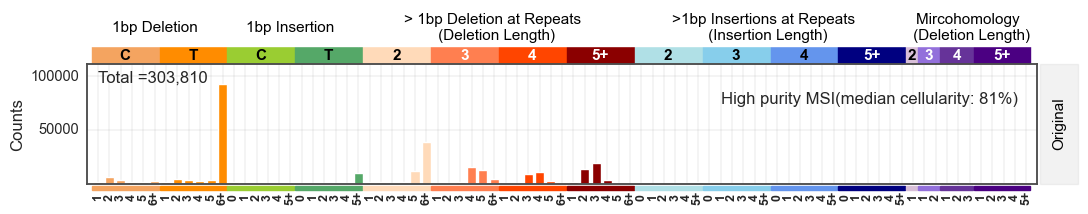

In [58]:
ID83_plot(high_purity_epicc_msi_mean_profile, 
          name = "High purity MSI(median cellularity: 81%)",label = "Original")

In [59]:
low_purity_epicc_msi_mean_profile = epicc_lowpass_df_t_msi.iloc[:, 96:179].loc[df_umap['estimated_purity'].values < 0.15, :].median().astype("int32")

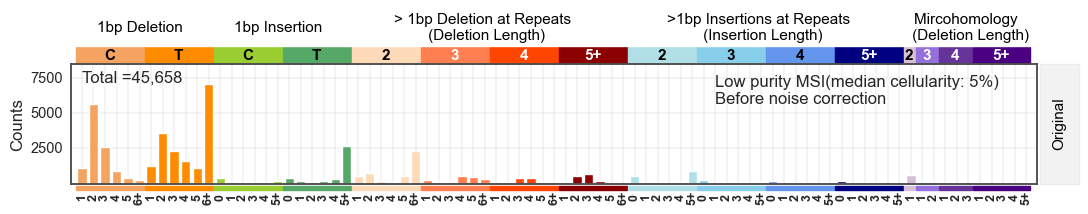

In [60]:
ID83_plot(low_purity_epicc_msi_mean_profile, 
          name = "Low purity MSI(median cellularity: 5%)\nBefore noise correction", label = "Original",
          file = "./Figures/MILO_Fig5b.pdf")

In [61]:
cosine_similarity(low_purity_epicc_msi_mean_profile.to_numpy().reshape(1,83), 
                  ff_lowpass_df_norm.groupby("data_source").get_group('EPICC_lpWGS').groupby('MSI_status').get_group(1).iloc[:,96:179].mean().to_numpy().reshape(1,83))

array([[0.76952267]])

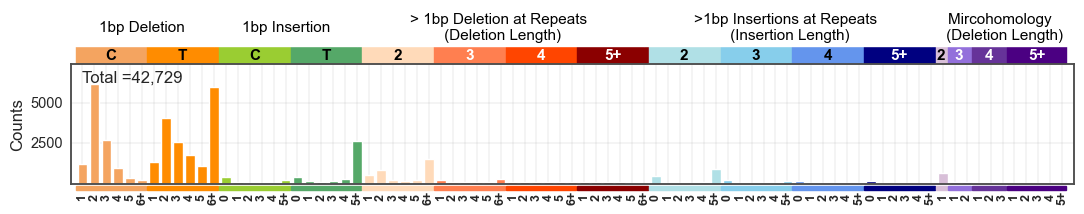

In [62]:
ID83_plot(epicc_lowpass_df_t.loc[epicc_lowpass_df_t['MSI_status'] == 0,
                                             :].iloc[:,96:179].median().astype("int"))

In [63]:
noise_profile =  epicc_lowpass_df_t_norm.loc[epicc_lowpass_df_t_norm['MSI_status'] == 0,
                                             :].iloc[:,96:179].mean().to_numpy()

In [64]:
corrected_profile, corrected_profiles_df = correct_FFPE_profile(V = low_purity_epicc_msi_mean_profile.to_numpy(), 
                                                                W1 = noise_profile,
                                                                sample_id= "Averaged_low_purity_profile",
                                                                precision = 0.99)

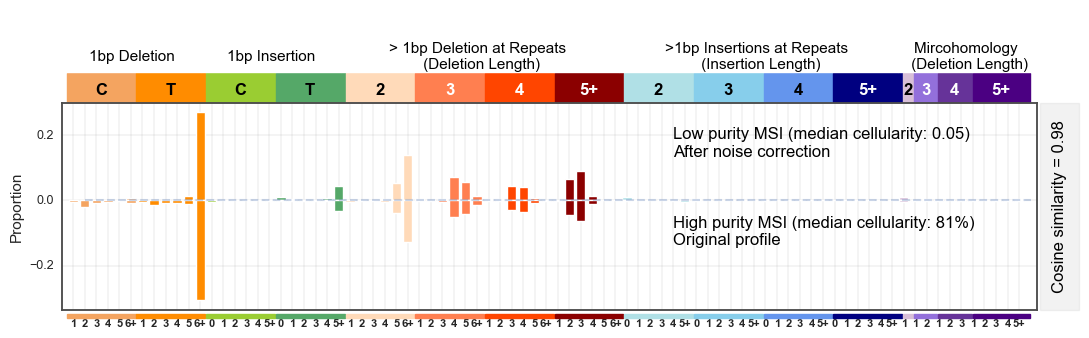

In [65]:
ID83_compare_profile(corrected_profile/sum(corrected_profile), 
                     high_purity_epicc_msi_mean_profile/sum(high_purity_epicc_msi_mean_profile), 
                     name1 = 'Low purity MSI (median cellularity: 0.05)\nAfter noise correction', 
                     name2 = 'High purity MSI (median cellularity: 81%)\nOriginal profile', 
                     label = 'Cosine similarity = 0.98', file = "./Figures/MILO_Fig5b.pdf")

In [66]:
cosine_similarity(corrected_profile.reshape(1,83), 
                  high_purity_epicc_msi_mean_profile.to_numpy().reshape(1,83))

array([[0.98068539]])

## Mutation burden vs sequencing coverage & tumour purity

In [67]:
long_deletion_cols = selected_features_FF[[s != '1_Del_T_5' for s in selected_features_FF]]

In [68]:
epicc_lowpass_df_t['Total_indel'] = epicc_lowpass_df_t.iloc[:, 96:179].sum(axis = 1).values
epicc_lowpass_df_t['Total_SNV'] = epicc_lowpass_df_t.iloc[:, :96].sum(axis = 1).values
long_ind = [col in long_deletion_cols for col in epicc_lowpass_df_t.columns]
epicc_lowpass_df_t['Total_long_indels'] = epicc_lowpass_df_t.loc[:, long_ind].sum(axis = 1).values
long_ind = [col in long_deletion_cols for col in epicc_lowpass_df_t_norm.columns]

In [69]:
epicc_lowpass_df_t['Normalised_Total_indel'] = (epicc_lowpass_df_t['Total_indel']/epicc_lowpass_df_t['Coverage'])
epicc_lowpass_df_t['Normalised_Total_SNV'] = (epicc_lowpass_df_t['Total_SNV']/epicc_lowpass_df_t['Coverage'])
epicc_lowpass_df_t['Normalised_long_indels'] = (epicc_lowpass_df_t['Total_long_indels']/epicc_lowpass_df_t['Coverage'])
epicc_lowpass_df_t['Normalised_1bp_indels'] = epicc_lowpass_df_t['1_Del_T_5']/epicc_lowpass_df_t['Coverage']

In [70]:
epicc_lowpass_df_t_mss = epicc_lowpass_df_t.loc[epicc_lowpass_df_t['MSI_status'].values == 0,:]
epicc_lowpass_df_t_msi = epicc_lowpass_df_t.loc[epicc_lowpass_df_t['MSI_status'].values == 1,:]

### Mutation burden vs Coverage

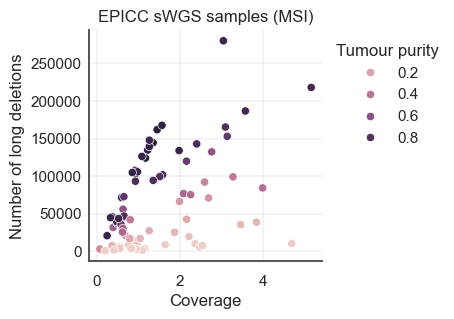

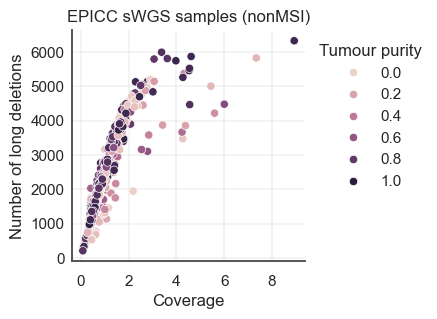

In [71]:
## MSI samples
f, ax = plt.subplots(figsize = (3, 3))
sns.scatterplot(x = 'Coverage', y = 'Total_long_indels', 
                data = epicc_lowpass_df_t_msi, hue = "estimated_purity")
sns.despine()
plt.legend (frameon = False, bbox_to_anchor = (1,1), title = "Tumour purity")
plt.ylabel("Number of long deletions")
plt.title("EPICC sWGS samples (MSI)")
plt.savefig("./Figures/MILO_SFig22a.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## nonMSI samples
f, ax = plt.subplots(figsize = (3, 3))
sns.scatterplot(x = 'Coverage', y = 'Total_long_indels', 
                data = epicc_lowpass_df_t_mss, hue = "estimated_purity")
plt.legend (frameon = False, bbox_to_anchor = (1,1), title = "Tumour purity")
plt.ylabel("Number of long deletions")
plt.title("EPICC sWGS samples (nonMSI)")

sns.despine()
plt.savefig("./Figures/MILO_SFig22b.pdf", bbox_inches = "tight", dpi = 300)

plt.show()

### Mutation burden vs tumour purity

Normalised long deletion number

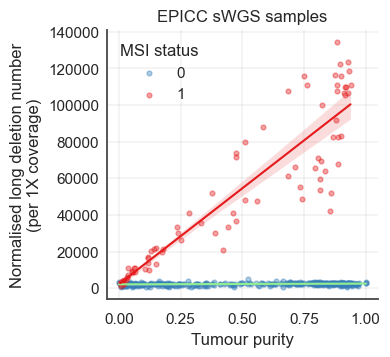

In [72]:
f, ax = plt.subplots(figsize = (3.5,3.5))

sns.regplot(x = 'estimated_purity', y = 'Normalised_long_indels',
            line_kws={'lw': 1.5, 'color': "lightgreen"}, 
            scatter_kws={'s': 12, 'alpha': 0.4, 'color':sns.color_palette("Set1")[1]},
            data = epicc_lowpass_df_t_mss , label= '0')

sns.regplot(x = 'estimated_purity', y = 'Normalised_long_indels',
            line_kws={'lw': 1.5, 'color': sns.color_palette("Set1")[0]}, 
            scatter_kws={'s': 12, 'alpha': 0.4, 'color':sns.color_palette("Set1")[0]},
            data = epicc_lowpass_df_t_msi,  label = '1')
plt.xlabel("Tumour purity")
plt.ylabel("Normalised long deletion number\n(per 1X coverage)")
plt.title("EPICC sWGS samples")
plt.legend(title = "MSI status", frameon = False)
sns.despine()
plt.show()

Normalised SNV number

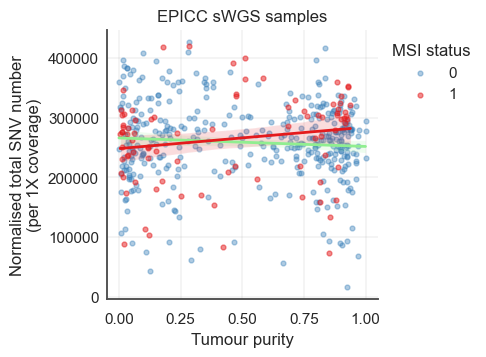

In [73]:
f, ax = plt.subplots(figsize = (3.5,3.5))

sns.regplot(x = 'estimated_purity', y = 'Normalised_Total_SNV',
            line_kws={'lw': 2, 'color': 'lightgreen'}, 
            scatter_kws={'s': 12, 'alpha': 0.4, 'color':sns.color_palette("Set1")[1]},
            data = epicc_lowpass_df_t_mss , label= '0')
sns.regplot(x = 'estimated_purity', y = 'Normalised_Total_SNV',
            line_kws={'lw': 2, 'color': sns.color_palette("Set1")[0]}, 
            scatter_kws={'s': 12, 'alpha': 0.5, 'color':sns.color_palette("Set1")[0]},
            data = epicc_lowpass_df_t_msi,  label = '1')
plt.xlabel("Tumour purity")

plt.ylabel("Normalised total SNV number\n(per 1X coverage)")

plt.title("EPICC sWGS samples")
plt.legend(title = "MSI status", bbox_to_anchor = (1,1), frameon = False)
sns.despine()
plt.savefig("./Figures/MILO_SFig23.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

Normalised total indel number

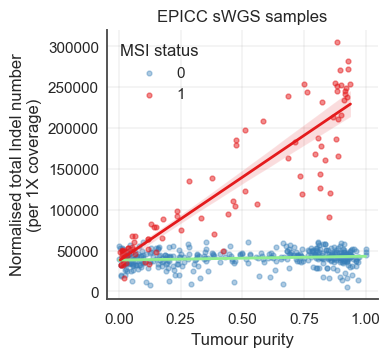

In [74]:
f, ax = plt.subplots(figsize = (3.5,3.5))

sns.regplot(x = 'estimated_purity', y = 'Normalised_Total_indel',
            line_kws={'lw': 2, 'color': 'lightgreen'}, 
            scatter_kws={'s': 12, 'alpha': 0.4, 'color':sns.color_palette("Set1")[1]},
            data = epicc_lowpass_df_t_mss , label= '0')
sns.regplot(x = 'estimated_purity', y = 'Normalised_Total_indel',
            line_kws={'lw': 2, 'color': sns.color_palette("Set1")[0]}, 
            scatter_kws={'s': 12, 'alpha': 0.5, 'color':sns.color_palette("Set1")[0]},
            data = epicc_lowpass_df_t_msi,  label = '1')
plt.xlabel("Tumour purity")

plt.ylabel("Normalised total Indel number\n(per 1X coverage)")

plt.title("EPICC sWGS samples")
plt.legend(title = "MSI status", frameon = False)
sns.despine()
plt.savefig("./Figures/MILO_Fig5e.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = epicc_lowpass_df_t_msi[['estimated_purity']]
y = epicc_lowpass_df_t_msi['Normalised_Total_indel'].to_numpy()

linr_model = LinearRegression().fit(X, y)
r_sq = linr_model.score(X, y)
linr_model.coef_, linr_model.intercept_, r_sq 

(array([204411.31248515]), 37472.60828187782, 0.8104642674778022)

# Comparing FFPE noise to FF noise

In [76]:
coverage_id_dict = {sid: reads_num for sid, reads_num in zip (masterlist['Sample_IDs'], 
                                                              masterlist['Coverage'])}
## adding coverage information in FFPE dataset
df_f['Coverage'] = [coverage_id_dict.get(sid, 0) for sid in df_f.index.values]

ind = np.logical_and (ff_lowpass_df['MSI_status'] == 0, ff_lowpass_df['data_source'] != 'EPICC_lpWGS')
FF_0_1X_long_del_noise_levels = ff_lowpass_df.loc[ind, long_deletion_cols].sum(axis = 1).values
normalised_FF_mss_long_dels = epicc_lowpass_df_t['Normalised_long_indels'].values

selected_features_FFPE_long_del = selected_features_FFPE[[f != '1_Del_T_5'for f in selected_features_FFPE]]

In [77]:
## normalising FFPE noise levels, from nonMSI samples, by the coverage
projected_FF_1x_long_del_num = np.median(FF_0_1X_long_del_noise_levels/0.1)
real_FF_1x_long_del_num = np.median(normalised_FF_mss_long_dels)
ajustment_ratio =  real_FF_1x_long_del_num/projected_FF_1x_long_del_num

normalised_FFPE_mss_total_indels = df_f.iloc[:, 96:179].loc[df_f['MSI_status'] == 0,                            
                                    :].sum(axis = 1) / df_f.loc[df_f['MSI_status'] == 0, 
                                                                'Coverage'] * ajustment_ratio

long_indel_ind_FFPE = [col in list(selected_features_FFPE_long_del) for col in df_f.columns]

normalised_FFPE_mss_long_dels = df_f.loc[df_f['MSI_status'] == 0, :].loc[:, 
                                long_indel_ind_FFPE].sum(axis = 1).values/df_f.loc[df_f['MSI_status'] == 0, 
                                'Coverage'] * ajustment_ratio

In [78]:
## read the normalised noise in FF samples
normalised_FF_mss_total_indels = epicc_lowpass_df_t_mss ['Normalised_Total_indel'].values
normalised_FF_mss_long_dels = epicc_lowpass_df_t_mss ['Normalised_long_indels'].values

In [79]:
noise_lp_df = pd.DataFrame({"Data" : ['Fresh frozen'] * len (normalised_FF_mss_total_indels) + ['FFPE'] * len (normalised_FFPE_mss_total_indels),
                            "Total indels": list(normalised_FF_mss_total_indels) + list (normalised_FFPE_mss_total_indels),
                           "Long deletions" : list (normalised_FF_mss_long_dels) + list (normalised_FFPE_mss_long_dels)})
noise_lp_df_melted = noise_lp_df.melt(id_vars = ['Data'])
noise_lp_df.head(2)

,Data,Total indels,Long deletions
0,Fresh frozen,32073.214499,2113.889221
1,Fresh frozen,43829.491256,3142.885533


In [80]:
noise_lp_df.groupby("Data").mean()

,Total indels,Long deletions
Data,,
FFPE,131436.430615,5599.541985
Fresh frozen,40736.311389,2335.466966


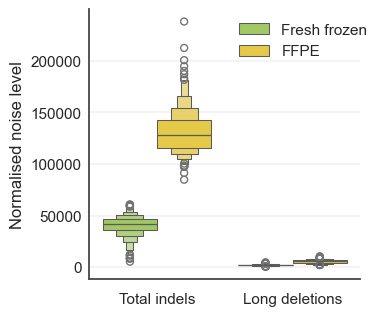

In [81]:
f, ax = plt.subplots (figsize = (3.5,3.5))
sns.boxenplot (x= "variable", y = "value", hue = "Data", 
               palette= {"Fresh frozen": sns.color_palette("Set2")[4], 
                         "FFPE": sns.color_palette("Set2")[5]},
               data = noise_lp_df_melted)
sns.despine()
plt.legend(frameon = False, bbox_to_anchor = (0.5, 1))
plt.ylabel("Normalised noise level")
plt.xlabel("")
plt.savefig ("./Figures/MILO_Fig5f.pdf", dpi = 300,  bbox_inches = "tight")
plt.show()

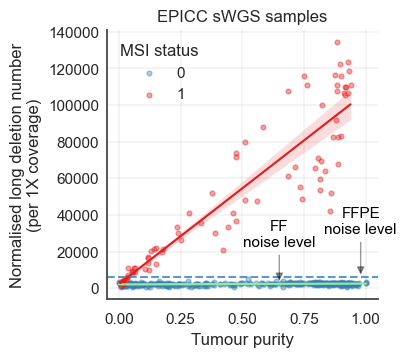

In [82]:
## adding median FFPE noise level to Fig5d1
f, ax = plt.subplots(figsize = (3.5,3.5))

sns.regplot(x = 'estimated_purity', y = 'Normalised_long_indels',
            line_kws={'lw': 1.5, 'color': "lightgreen"}, 
            scatter_kws={'s': 12, 'alpha': 0.4, 'color':sns.color_palette("Set1")[1]},
            data = epicc_lowpass_df_t_mss , label= '0')

sns.regplot(x = 'estimated_purity', y = 'Normalised_long_indels',
            line_kws={'lw': 1.5, 'color': sns.color_palette("Set1")[0]}, 
            scatter_kws={'s': 12, 'alpha': 0.4, 'color':sns.color_palette("Set1")[0]},
            data = epicc_lowpass_df_t_msi,  label = '1')
plt.xlabel("Tumour purity")
plt.ylabel("Normalised long deletion number\n(per 1X coverage)")
plt.title("EPICC sWGS samples")

FFPE_noise_level = noise_lp_df.groupby("Data").median().loc["FFPE", :].values[1]
plt.axhline(FFPE_noise_level, linestyle = "--", 
            color =sns.color_palette("Set1")[1], alpha = 0.8)

plt.annotate("FFPE\nnoise level",xy = (0.98, FFPE_noise_level), 
              ha='center',
             xytext = (0.98, 30000), size = 11, color = "black", 
             arrowprops=dict(color='black', arrowstyle='-|>',
                             linewidth=1, alpha = 0.4) )

plt.annotate("FF\nnoise level",xy = (0.65, real_FF_1x_long_del_num), 
              ha='center',
             xytext = (0.65, 23000), size = 11, color = "black",
             
             arrowprops=dict(color='black', arrowstyle='-|>',
                             linewidth=1, alpha = 0.4) )
             
plt.legend(title = "MSI status", frameon = False)
sns.despine()
plt.savefig("./Figures/MILO_Fig5d1.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

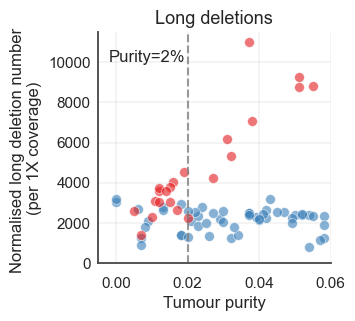

In [83]:
f, ax = plt.subplots(figsize = (3,3))

sns.scatterplot(x = 'estimated_purity', y = 'Normalised_long_indels', 
                color = sns.color_palette("Set1")[1], s = 50, alpha = 0.6,
                data = epicc_lowpass_df_t_mss)
sns.scatterplot(x = 'estimated_purity', y = 'Normalised_long_indels',
                color = sns.color_palette("Set1")[0], s = 50, alpha = 0.6,
                data = epicc_lowpass_df_t_msi)
plt.xlim(-0.005,0.06)
plt.ylim(0,11500)
plt.axvline(0.020, linestyle = "--", color = "grey", alpha = 0.8)
plt.annotate("Purity=2%", (-0.002, 10000))
plt.xlabel("Tumour purity", size = 12)
plt.ylabel("Normalised long deletion number \n(per 1X coverage)", size = 12)
sns.despine()
plt.title("Long deletions", size = 13)
plt.savefig("./Figures/MILO_Fig5d2.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

# Development of MILO

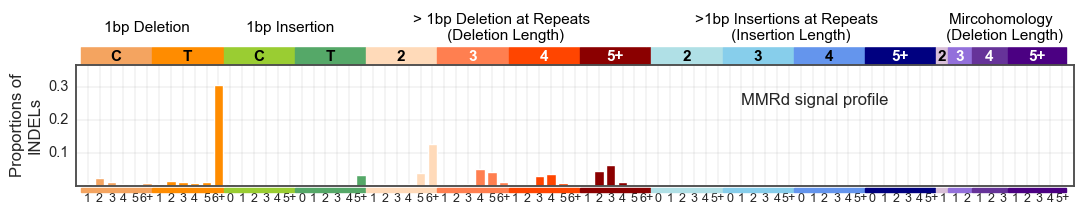

In [84]:
signal_profile_tmp = epicc_lowpass_df_t_norm_msi.iloc[:,96:179].loc[
    df_umap['estimated_purity'].values > 0.9, :].mean()
signal_profile = signal_profile_tmp/signal_profile_tmp.sum()
ID83_plot (signal_profile, norm = True, name = "MMRd signal profile")

## Simulating FF samples

### Simulating MSI samples

Build a linear regression model to predict MMRd total indel numbers using varied purity input

In [85]:
n_shape = epicc_lowpass_df_t_msi.shape[0]
X = epicc_lowpass_df_t_msi[['estimated_purity']].to_numpy().reshape ([n_shape,1])
y = epicc_lowpass_df_t_msi['Normalised_Total_indel'].to_numpy()

linr_model = LinearRegression().fit(X, y)
r_sq = linr_model.score(X, y)
print (f"slope: {linr_model.coef_[0]:.2f}, intercept: {linr_model.intercept_:.2f}, goodness_of_fit: {r_sq:.2f}")

slope: 204411.31, intercept: 37472.61, goodness_of_fit: 0.81


In [86]:
np.random.seed (123)
FF_purity_threshold = 0.02
purity_upperbound = 0.1
sample_size = 10000

## generating random purity input:
simulated_purities1 = np.random.uniform(low = FF_purity_threshold, 
                                       high=0.2, 
                                       size = int(sample_size/2))

simulated_purities2 = np.random.uniform(low = FF_purity_threshold, 
                                       high=0.99, 
                                       size = int(sample_size/2))

simulated_purities = np.array(list(simulated_purities1) + list(simulated_purities2))

X_simulated = simulated_purities.reshape (sample_size, 1)

## predict total indel burden using the model
y_simulated = np.random.poisson (linr_model.predict(X_simulated))

## simulate noise level and signal level in MMRd samples
noise_level_simulated = np.random.poisson(linr_model.intercept_, size = sample_size)
signal_level_simulated = y_simulated - noise_level_simulated

In [87]:
## using random MMRp samples as noise profiles
non_epicc_mss_samples_ind = np.logical_and (ff_lowpass_df_norm['MSI_status'] == 0,
                                       ff_lowpass_df_norm['data_source'] != 'EPICC_lpWGS')

FF_noise_profile_candidates = ff_lowpass_df_norm.loc[non_epicc_mss_samples_ind, 
                                                     :].iloc[:,96:179].copy()

noise_num_upper_range = FF_noise_profile_candidates.shape[0]

rand_noise_ind = (np.random.uniform(low = 0, 
                                    high = noise_num_upper_range, 
                                    size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles

to_mix_noise = FF_noise_profile_candidates.iloc [rand_noise_ind,:].T
ready_to_mix_noise = np.random.poisson(to_mix_noise * noise_level_simulated)

## add signal levels to signal profile
to_mix_signal = pd.DataFrame ({'sample_' + str(i) : 
                               signal_profile for i in range(sample_size)})
ready_to_mix_signal = np.random.poisson(to_mix_signal * signal_level_simulated)

## mix noise and signal together

simulated_MMRd_samples = pd.DataFrame ({'msi_sample_' + str(i) : [0] * 83 for i in range(sample_size)})
simulated_MMRd_samples.loc[:,:] = ready_to_mix_noise + ready_to_mix_signal

## record purities in simulated datasets
simulated_MMRd_samples_t = simulated_MMRd_samples.T
simulated_MMRd_samples_t.loc[:, 'purity'] = simulated_purities

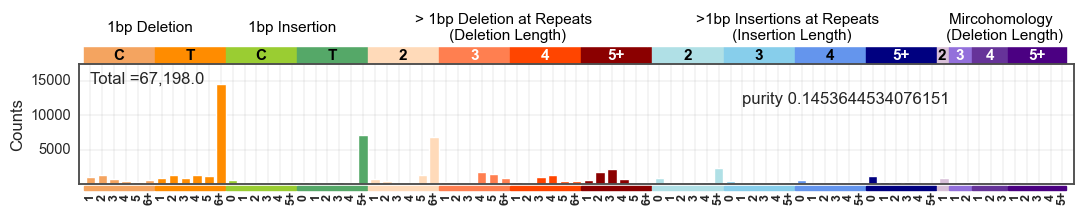

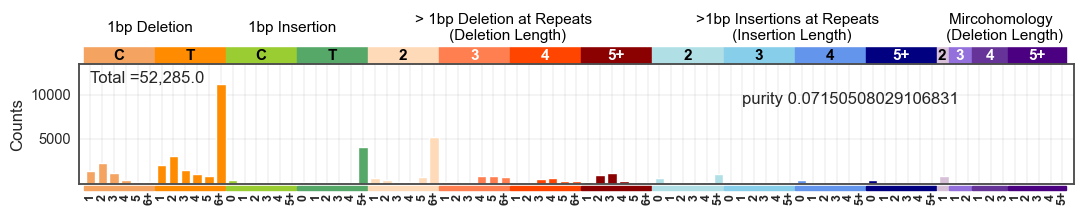

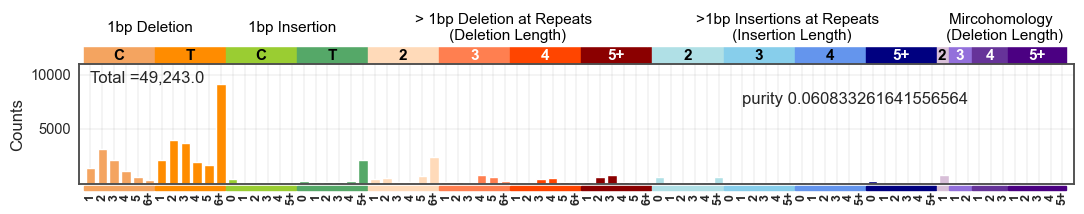

In [88]:
## Examples of simulated MMRd samples
for s in simulated_MMRd_samples_t.index[:3]:
    ID83_plot(simulated_MMRd_samples_t.loc[s, :][:83], 
              name = f"purity {simulated_MMRd_samples_t.loc[s, 'purity']}")

### Simulating nonMSI samples

In [89]:
np.random.seed (1245)
FF_median_noise = noise_lp_df.groupby("Data").median()['Total indels'][1]

noise_level_simulated2 = np.random.poisson(FF_median_noise, size = sample_size)

rand_noise_ind2 = (np.random.uniform(low = 0, 
                                    high = noise_num_upper_range, 
                                    size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles
rand_nonMSI_profiles = FF_noise_profile_candidates.iloc [rand_noise_ind2,:].T
simulated_nonMSI_samples = pd.DataFrame ({'nonmsi_sample_' + str(i) : [0] * 83 
                                        for i in range(sample_size)})

simulated_nonMSI_samples.loc[:,:] = np.random.poisson(rand_nonMSI_profiles * noise_level_simulated2)

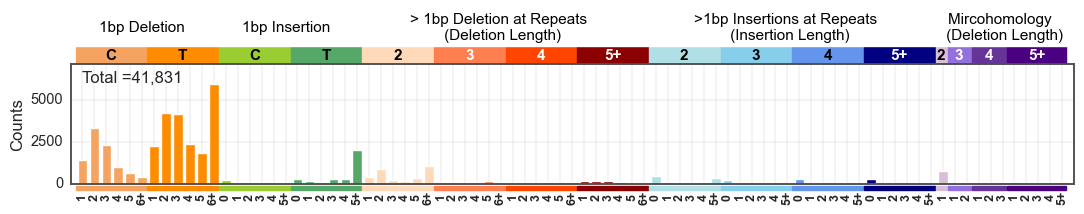

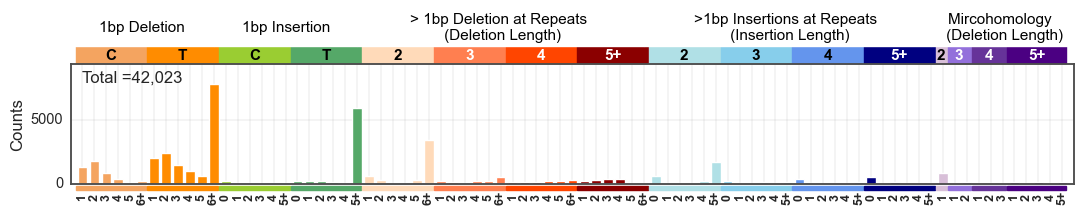

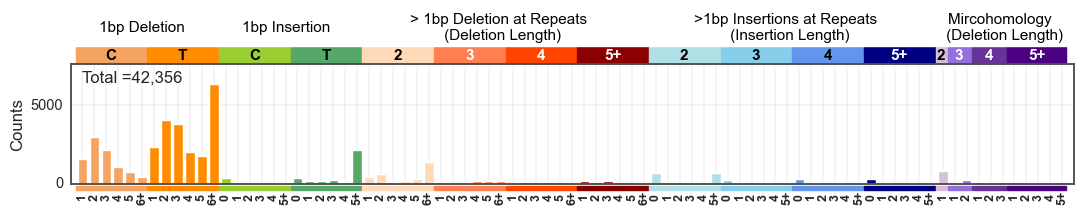

In [90]:
## Examples of simulated MMRp samples

for col in simulated_nonMSI_samples.columns[:3]:
    ID83_plot(simulated_nonMSI_samples[col])

### Merge simulated MSI and nonMSI samples

In [91]:
simulated_MMRd_samples_t_norm_tmp = (simulated_MMRd_samples / simulated_MMRd_samples.sum()).T
simulated_MMRd_samples_t_norm = simulated_MMRd_samples_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_MMRd_samples_t_norm['MSI_status'] = 1

In [92]:
simulated_nonMSI_samples_t_norm_tmp = (simulated_nonMSI_samples / simulated_nonMSI_samples.sum()).T
simulated_nonMSI_samples_t_norm = simulated_nonMSI_samples_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_nonMSI_samples_t_norm['MSI_status'] = 0

In [93]:
combined_simulated_FF_samples = pd.concat((simulated_MMRd_samples_t_norm, 
                                           simulated_nonMSI_samples_t_norm))

combined_simulated_FF_samples.shape

(20000, 84)

### Model selection on simulated datasets

In [94]:
def compute_scores(cf_matrix, f=None, target_names=None, title = None):
    metrics_results = dict()
    
    precision = cf_matrix[1, 1] / sum(cf_matrix[:, 1])
    recall    = cf_matrix[1, 1] / sum(cf_matrix[1,:])
    accuracy  = np.trace(cf_matrix) / float(np.sum(cf_matrix))
    f1_score  = 2 * precision * recall / (precision + recall)
    
    metrics_results['f1_score'] = f1_score
    metrics_results['precision'] = precision
    metrics_results['recall'] = recall
    metrics_results['accuracy'] = accuracy

    group_names = ['TN', 'FP', 'FN', 'TP']
    group_counts = ["{0:.0f}".format(value) for value in 
                    cf_matrix.flatten()]
    for gn, gc in zip (group_names, group_counts):
        metrics_results[gn + "_count"] = gc
        
    group_percentages = ["{0:.2%}".format(value) for value in 
                         cf_matrix.flatten()/np.sum(cf_matrix)]
    
    for gn, gp in zip (group_names, group_percentages):
        metrics_results[gn + "_perc"] = gp
        
    precision = cf_matrix[1, 1] / sum(cf_matrix[:, 1])
    recall    = cf_matrix[1, 1] / sum(cf_matrix[1,:])
    accuracy  = np.trace(cf_matrix) / float(np.sum(cf_matrix))
    f1_score  = 2 * precision * recall / (precision + recall)
    
    return (metrics_results)

def model_prediction (x_train, y_train, x_test, y_test, model, title = "", plot = False):
    from sklearn import svm  
    ml = model.fit(x_train, y_train)
    cm = confusion_matrix(y_test, ml.predict(x_test))
        
    if plot:
        plot_confusion_matrix(cm, title = title)
        
    cm = confusion_matrix(y_test, ml.predict(x_test))
    
    return (compute_scores(cm))

    #return (f1_score(y_test, model.predict(x_test[feature])))
    
def run_models (x_train, y_train, x_test, y_test):
    scores = dict()
    from sklearn import svm

    model_order = dict({"Random forest" : RandomForestClassifier(),
                       "SVM":svm.SVC(kernel='rbf', probability=True),
                       "Naive Bayes":GaussianNB()})
    for name, model in model_order.items():
        #print (name)
        matrics_scores = model_prediction (x_train, y_train, x_test, y_test, model= model, title = name)
        scores[name] = matrics_scores
        
    return (scores)

In [95]:
X = combined_simulated_FF_samples.loc[:, selected_features_FF].to_numpy()
encoder = LabelEncoder()
encoder.fit(combined_simulated_FF_samples['MSI_status'])
y = encoder.transform(combined_simulated_FF_samples['MSI_status'])

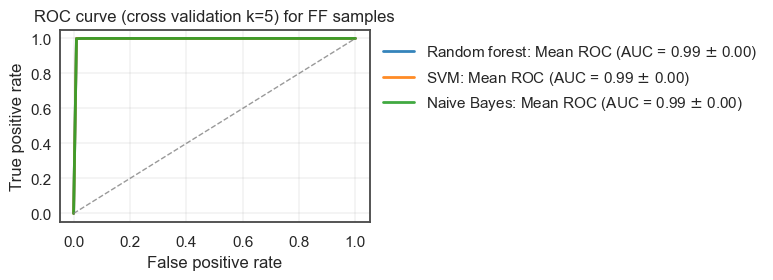

In [96]:
from sklearn import svm
fig, ax = plt.subplots(figsize = (4,2.5))
colors = sns.color_palette("tab10")[:3]
for model, name, c in zip([RandomForestClassifier(), svm.SVC(kernel='rbf', probability=True), GaussianNB()], 
                          ["Random forest", "SVM", "Naive Bayes"], 
                          colors):
    
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=413)
    
    for i, (train, test) in enumerate(cv.split(X, y)):
        #print ("batch" + str(i + 1), "\n -------------------------\n")
        from sklearn import svm
        ml = model.fit(X[train], y[train])
        
        fpr, tpr, threshold = metrics.roc_curve(y[test], ml.predict_proba(X[test])[:,1])
        roc_auc = metrics.auc(fpr, tpr)
        #print (ml)
        
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)
        
        y_predict = ml.predict(X[test])
        
        FP_index = np.logical_and (y[test] == False, y_predict == True)
        FN_index = np.logical_and (y[test] == True, y_predict == False)
        
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = metrics.auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    ax.plot(mean_fpr, mean_tpr, color= c,
            label=name + ": " + r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
            lw=2, alpha= 0.9)

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="ROC curve (cross validation k=5) for FF samples")

ax.plot([0, 1], [0, 1], linestyle='--', lw=1, color='grey',
        label='', alpha=.8)
ax.legend(bbox_to_anchor = (1,1), frameon=False)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")

plt.savefig("./Figures/MILO_SFig24a.pdf", bbox_inches = "tight", dpi = 300,
            facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [97]:
from sklearn import svm

model_names, model_scores = [], []
split_num = 5
n = 0
        
for i in range(50):

    np.random.seed(i + 1)
    n += 1
    print (n)
    
    cv = StratifiedKFold(n_splits=split_num, shuffle=True, random_state= i+1)
    
    #kfold = StratifiedKFold(n_splits = split_num, shuffle=True)

    for train, test in cv.split(X, y):
        
        x_train, x_test = X[train], X[test]
        y_train, y_test = y[train], y[test]
        
        scores_per_batch = run_models(x_train, y_train, x_test, y_test)
        
        for model_n, f1_s in scores_per_batch.items():
            model_names.append(model_n)
            model_scores.append(f1_s)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [98]:
uniq_m = list(scores_per_batch.keys())
uniq_sn = list(scores_per_batch['Random forest'].keys())
model_list =[]
score_names = []
scores = []

for m, inner_sn_dict in zip (model_names, model_scores):
    for sn in uniq_sn:
        model_list.append(m)
        score_names.append(sn)
        scores.append(inner_sn_dict.get (sn))
        
model_comparison_df_complete = pd.DataFrame({"Models":model_list,"Measures":score_names, "Scores": scores})
model_comparison_df_complete.head()

,Models,Measures,Scores
0,Random forest,f1_score,1.0
1,Random forest,precision,1.0
2,Random forest,recall,1.0
3,Random forest,accuracy,1.0
4,Random forest,TN_count,2000


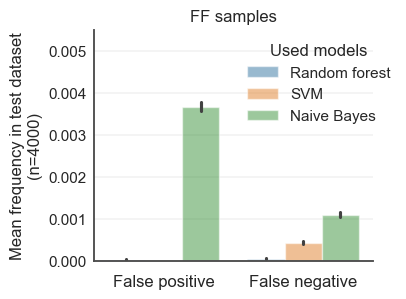

In [99]:
model_comparison_df_complete_count_vis = model_comparison_df_complete.loc[[m in ['FN_count','FP_count'] 
                                  for m in model_comparison_df_complete.Measures],:].copy()
model_comparison_df_complete_count_vis.Scores = model_comparison_df_complete_count_vis.Scores.astype("float64")/len(y_test)


f, ax = plt.subplots(figsize = (3.6,3))
sns.barplot (x = "Measures", y = "Scores", hue = "Models", alpha=.5,
            data = model_comparison_df_complete_count_vis, 
             palette= "tab10")

plt.xlabel("")
plt.ylabel("Mean frequency in test dataset\n(n=4000)", fontsize = 12)
plt.ylim(0,0.0055)
plt.title ("FF samples")
plt.xticks([0,1], ["False positive", "False negative"], fontsize = 12)
plt.legend(title = "Used models", bbox_to_anchor = (0.5,1), frameon = False, ncol = 1)

sns.despine()
plt.savefig("./Figures/MILO_SFig24c.pdf", bbox_inches = "tight", dpi = 300,
            facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [100]:
model_comparison_df_complete_count_vis.groupby(['Measures', 'Models']).mean()

Scores
Measures Models                 
FN_count Naive Bayes    0.001095
         Random forest  0.000050
         SVM            0.000427
FP_count Naive Bayes    0.003660
         Random forest  0.000022
         SVM            0.000000

### Train the model and test it on indepedent FF dataset

In [101]:
def plot_confusion_matrix(cf_matrix, f=None, target_names=None, title = None):

    group_names = ['TN', 'FP', 'FN', 'TP']
    group_counts = ["{0:.0f}".format(value) for value in 
                    cf_matrix.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in 
                         cf_matrix.flatten()/np.sum(cf_matrix)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in 
              zip(group_names,
                  group_counts,
                  group_percentages)
             ]
    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize = (3.5, 2))
    sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues',  annot_kws={"size": 11})
    if target_names:
        tick_marks = range(len(target_names))
        plt.xticks(tick_marks, target_names,ha='right')
        plt.yticks(tick_marks, target_names,ha='center')
    if title:
        plt.title (title,fontsize = 12)

    precision = cf_matrix[1, 1] / sum(cf_matrix[:, 1])
    recall    = cf_matrix[1, 1] / sum(cf_matrix[1,:])
    accuracy  = np.trace(cf_matrix) / float(np.sum(cf_matrix))
    f1_score  = 2 * precision * recall / (precision + recall)
    
    stats_text = "Precision={:0.2f}; Recall={:0.2f};\nAccuracy={:0.2f}; F1 Score={:0.2f}".format(
        precision, recall, accuracy, f1_score)
    
    plt.xlabel('Predicted label\n\n{}'.format(stats_text), fontsize = 11)
    plt.ylabel("True Label",fontsize = 11)
    if f:
        plt.savefig(f, bbox_inches = "tight", dpi = 300)
    plt.show()

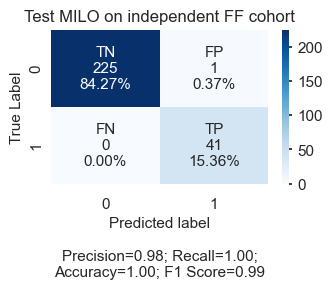

In [102]:
rf = RandomForestClassifier()
npr.seed (13)
rf_model = rf.fit(X, y)
epicc_ff_cohort = ff_lowpass_df_norm.loc[ff_lowpass_df_norm['data_source'] == 'EPICC_lpWGS', :].copy()
x_test = epicc_ff_cohort.loc[:, selected_features_FF].to_numpy()
y_test_true = epicc_ff_cohort['MSI_status'].values
y_test_predict = rf_model.predict(x_test)
y_test_pred_probs = rf_model.predict_proba (x_test)
cm = confusion_matrix(y_test_true, y_test_predict)
plot_confusion_matrix(cm, title = "Test MILO on independent FF cohort", 
                      f = './Figures/MILO_SFig25a.pdf')

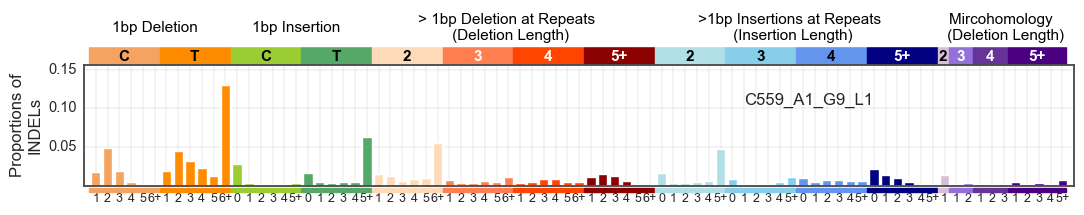

In [103]:
outliers = epicc_ff_cohort.loc [y_test_true - rf_model.predict(x_test) != 0, :]
for s in outliers.index:
    ID83_plot(outliers.loc[s,:][96:179], name = s, norm = True)

In [104]:
print ("prediction probility of the outlier", y_test_pred_probs[epicc_ff_cohort.index == s])

prediction probility of the outlier [[0.28 0.72]]


## Simulate FFPE samples

### MSI samples

In [105]:
FFPE_median_noise = noise_lp_df.groupby("Data").median()['Total indels'][0]
FF_median_noise = noise_lp_df.groupby("Data").median()['Total indels'][1]

In [106]:
FFPE_purity_threshold = 0.05
sample_size = 10000
np.random.seed (1234)

simulated_purities1 = np.random.uniform(low = FFPE_purity_threshold, 
                                       high=0.2, 
                                       size = int(sample_size/2))

simulated_purities2 = np.random.uniform(low = FFPE_purity_threshold, 
                                       high=0.99, 
                                       size = int(sample_size/2))

simulated_purities = np.array(list(simulated_purities1) + list(simulated_purities2))

X_simulated = simulated_purities.reshape (sample_size, 1)

## FFPE additional noise

additional_FFPE_noise = FFPE_median_noise - FF_median_noise

## predict total indel burden using the linear model (with additional FFPE noise)
y_simulated = np.random.poisson (linr_model.predict(X_simulated) + additional_FFPE_noise)

In [107]:
mu = linr_model.intercept_ + additional_FFPE_noise

np.random.seed (3212)

FFPE_noise_level_simulated = np.random.poisson(mu, size = sample_size)
FFPE_signal_level_simulated = y_simulated - FFPE_noise_level_simulated

In [108]:
## using random MMRp FFPE samples as noise profiles
non_duodenal_mss_sample_ind = np.logical_and (df_f_norm['MSI_status'] == 0,
                                             df_f_norm['cohort'] != 'Duodenal cancer')

FFPE_noise_profile_candidates = df_f_norm.loc[non_duodenal_mss_sample_ind, 
                                                     :].iloc[:,96:179].copy()
noise_num_upper_range = FFPE_noise_profile_candidates.shape[0]

FFPE_rand_noise_ind = (np.random.uniform(low = 0, 
                                        high = noise_num_upper_range, 
                                        size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles
FFPE_ready_to_mix_noise = np.random.poisson(FFPE_noise_profile_candidates.iloc [FFPE_rand_noise_ind,
                                              :].T * FFPE_noise_level_simulated)

## add signal levels to signal profile
FFPE_to_mix_signal = pd.DataFrame ({'sample_' + str(i) : 
                                   signal_profile for i in range(sample_size)})

FFPE_ready_to_mix_signal = np.random.poisson(FFPE_to_mix_signal * FFPE_signal_level_simulated)

## mix noise and signal together

simulated_MMRd_samples_FFPE = pd.DataFrame ({'sample_' + str(i) : [0] * 83 for i in range(sample_size)})
simulated_MMRd_samples_FFPE.loc[:,:] = FFPE_ready_to_mix_noise + FFPE_ready_to_mix_signal

## record purities in simulated datasets
simulated_MMRd_samples_FFPE_t = simulated_MMRd_samples_FFPE.T
simulated_MMRd_samples_FFPE_t.loc[:, 'purity'] = simulated_purities

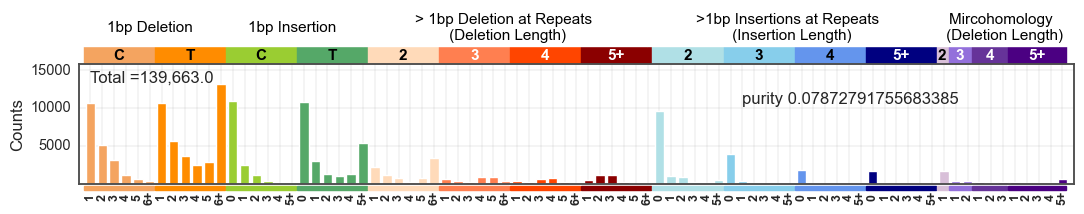

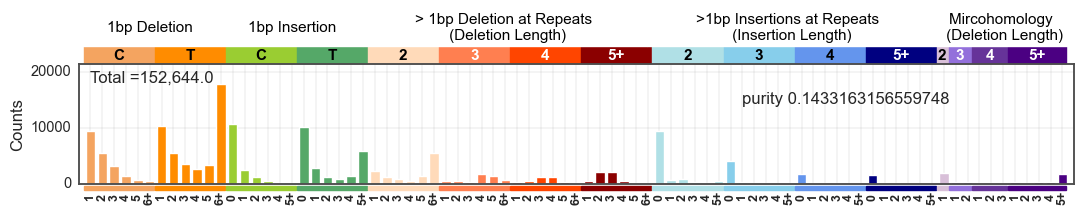

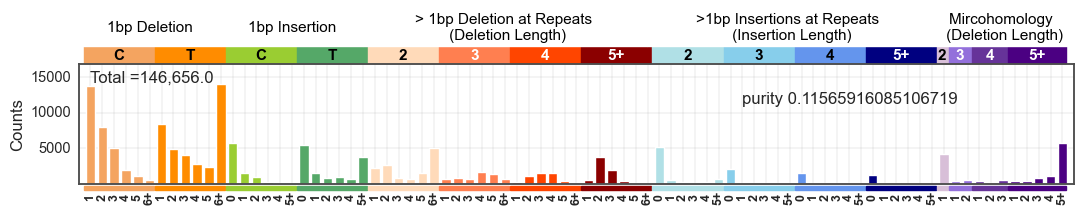

In [109]:
## Example of simulated FFPE MMRd samples
for s in simulated_MMRd_samples_FFPE_t.index[:3]:
    ID83_plot(simulated_MMRd_samples_FFPE_t.loc[s, :][:83], 
              name = f"purity {simulated_MMRd_samples_FFPE_t.loc[s, 'purity']}")

### Simulating nonMSI samples

In [110]:
np.random.seed (1345)
noise_level_simulated2 = np.random.poisson(FFPE_median_noise, size = sample_size)

noise_num_upper_range = FFPE_noise_profile_candidates.shape[0]

rand_noise_ind2 = (np.random.uniform(low = 0, 
                                    high = noise_num_upper_range, 
                                    size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles
FFPE_rand_nonMSI_profiles = FFPE_noise_profile_candidates.iloc [rand_noise_ind2,:].T
simulated_nonMSI_FFPE_samples = pd.DataFrame ({'nonmsi_sample_' + str(i) : [0] * 83 
                                        for i in range(sample_size)})

simulated_nonMSI_FFPE_samples.loc[:,:] = np.random.poisson(FFPE_rand_nonMSI_profiles * noise_level_simulated2)

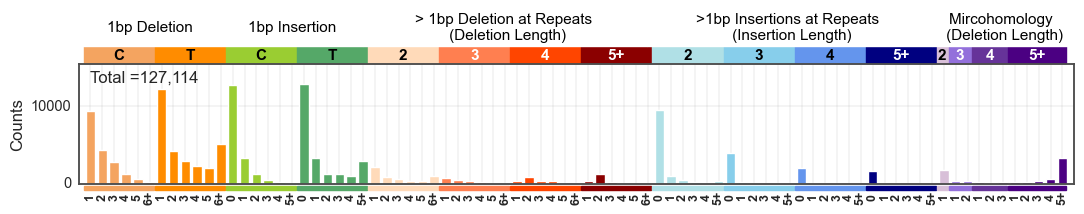

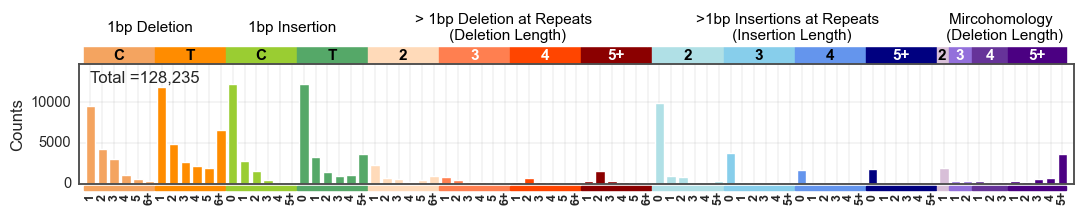

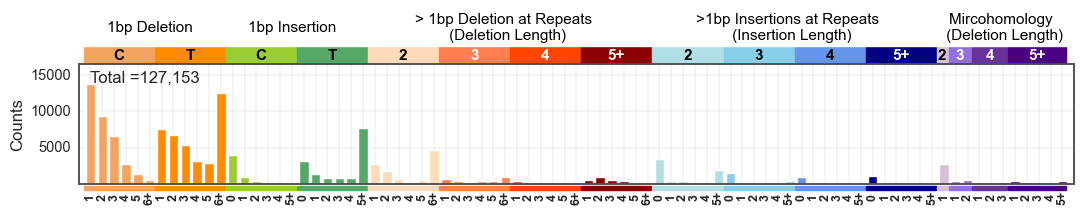

In [111]:
## Example of simulated FFPE MMRp samples

for col in simulated_nonMSI_FFPE_samples.columns[:3]:
    ID83_plot(simulated_nonMSI_FFPE_samples[col])

### Merge simulated FFPE MSI and nonMSI samples into one dataset

In [112]:
simulated_MMRd_samples_FFPE_t_norm_tmp = (simulated_MMRd_samples_FFPE / simulated_MMRd_samples_FFPE.sum()).T
simulated_MMRd_samples_FFPE_t_norm = simulated_MMRd_samples_FFPE_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_MMRd_samples_FFPE_t_norm['MSI_status'] = 1

In [113]:
simulated_nonMSI_FFPE_samples_t_norm_tmp = (simulated_nonMSI_FFPE_samples / simulated_nonMSI_FFPE_samples.sum()).T
simulated_nonMSI_FFPE_samples_t_norm = simulated_nonMSI_FFPE_samples_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_nonMSI_FFPE_samples_t_norm['MSI_status'] = 0

In [114]:
combined_simulated_FFPE_samples = pd.concat((simulated_MMRd_samples_FFPE_t_norm, 
                                           simulated_nonMSI_FFPE_samples_t_norm))

combined_simulated_FFPE_samples.shape

(20000, 84)

### Model selection

In [115]:
X = combined_simulated_FFPE_samples.loc[:, selected_features_FFPE].to_numpy()#.drop("MSI_status", axis = 1).to_numpy()
encoder = LabelEncoder()
encoder.fit(combined_simulated_FFPE_samples['MSI_status'])
y = encoder.transform(combined_simulated_FFPE_samples['MSI_status'])

In [116]:
from sklearn import svm

rf = RandomForestClassifier()
nb = GaussianNB()
svm = svm.SVC(kernel='rbf', probability=True)

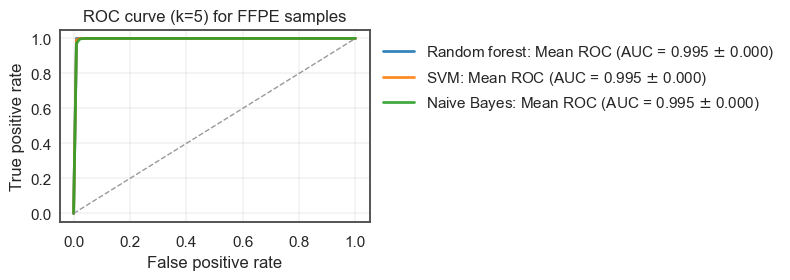

In [117]:
from sklearn import svm

fig, ax = plt.subplots(figsize = (4,2.5))
colors = sns.color_palette("tab10")[:3]
for model, name, c in zip([RandomForestClassifier(), svm.SVC(kernel='rbf', probability=True), GaussianNB()], 
                          ["Random forest", "SVM", "Naive Bayes"], 
                          colors):    
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=413)
    
    for i, (train, test) in enumerate(cv.split(X, y)):
        #print ("batch" + str(i + 1), "\n -------------------------\n")
        ml = model.fit(X[train], y[train])
        
        fpr, tpr, threshold = metrics.roc_curve(y[test], ml.predict_proba(X[test])[:,1])
        roc_auc = metrics.auc(fpr, tpr)
        #print (ml)
        
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)
        
        y_predict = ml.predict(X[test])
        
        FP_index = np.logical_and (y[test] == False, y_predict == True)
        FN_index = np.logical_and (y[test] == True, y_predict == False)
        
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = metrics.auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    ax.plot(mean_fpr, mean_tpr, color= c,
            label=name + ": " + r'Mean ROC (AUC = %0.3f $\pm$ %0.3f)' % (mean_auc, std_auc),
            lw=2, alpha= 0.9)

ax.set(xlim =[-0.05, 1.05], ylim = [-0.05, 1.05],
       title = "ROC curve (k=5) for FFPE samples")

ax.plot([0, 1], [0, 1], linestyle='--', lw=1, color='grey',
        label='', alpha=.8)
plt.legend(bbox_to_anchor = (1,1), frameon = False)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.savefig("./Figures/MILO_SFig24b.pdf", 
            bbox_inches = "tight", dpi = 300,facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [118]:
from sklearn import svm

model_names, model_scores = [], []
split_num = 5
n = 0        
        
for i in range(50):

    np.random.seed(i + 1)
    n += 1
    print (n)
    
    cv = StratifiedKFold(n_splits=split_num, shuffle=True, random_state= i+1)
    
    for train, test in cv.split(X, y):
        
        x_train, x_test = X[train], X[test]
        y_train, y_test = y[train], y[test]
        
        scores_per_batch = run_models(x_train, y_train, x_test, y_test)
        
        for model_n, f1_s in scores_per_batch.items():
            model_names.append(model_n)
            model_scores.append(f1_s)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [119]:
uniq_m = list(scores_per_batch.keys())
uniq_sn = list(scores_per_batch['Random forest'].keys())
model_list =[]
score_names = []
scores = []

for m, inner_sn_dict in zip (model_names, model_scores):
    for sn in uniq_sn:
        model_list.append(m)
        score_names.append(sn)
        scores.append(inner_sn_dict.get (sn))
        
model_comparison_df_complete = pd.DataFrame({"Models":model_list,
                                             "Measures":score_names, 
                                             "Scores": scores})
model_comparison_df_complete.head(2)

,Models,Measures,Scores
0,Random forest,f1_score,1.0
1,Random forest,precision,1.0


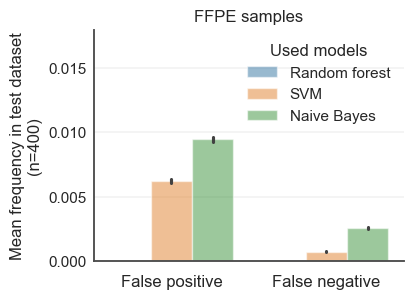

In [120]:
model_comparison_df_complete_count_vis = model_comparison_df_complete.loc[[m in ['FN_count','FP_count'] 
                                  for m in model_comparison_df_complete.Measures],:].copy()
model_comparison_df_complete_count_vis.Scores = model_comparison_df_complete_count_vis.Scores.astype("float64")/len(y_test)

f, ax = plt.subplots(figsize = (4,3))
sns.barplot (x = "Measures", y = "Scores", hue = "Models", alpha=.5,
            data = model_comparison_df_complete_count_vis, 
             palette= "tab10")

plt.xlabel("")
plt.ylabel("Mean frequency in test dataset\n(n=400)", fontsize = 12)
plt.ylim(0, 0.018)
plt.xticks([0,1], ["False positive", "False negative"], fontsize = 12)
plt.legend(title = "Used models", frameon = False, ncol = 1)
plt.title ("FFPE samples")
sns.despine()
plt.savefig("./Figures/MILO_SFig24d.pdf", bbox_inches = "tight", 
            dpi = 300,facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [121]:
model_comparison_df_complete_count_vis.groupby(['Measures', 'Models']).mean()

Scores
Measures Models                 
FN_count Naive Bayes    0.002567
         Random forest  0.000050
         SVM            0.000701
FP_count Naive Bayes    0.009450
         Random forest  0.000000
         SVM            0.006200

### Validate MILO on independent cancer samples

In [122]:
X = combined_simulated_FFPE_samples.loc[:, selected_features_FFPE].to_numpy()#.drop("MSI_status", axis = 1).to_numpy()
encoder = LabelEncoder()
encoder.fit(combined_simulated_FFPE_samples['MSI_status'])
y = encoder.transform(combined_simulated_FFPE_samples['MSI_status'])

In [123]:
X.shape

(20000, 10)

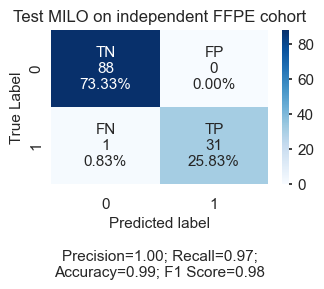

In [124]:
rf = RandomForestClassifier()
npr.seed(124)
rf_model = rf.fit(X, y)
duodenal_ffpe_cohort = df_f_norm.loc[df_f_norm['cohort'] == 'Duodenal cancer', :].copy()
x_test = duodenal_ffpe_cohort.loc[:, selected_features_FFPE].to_numpy()
y_test_true = duodenal_ffpe_cohort['MSI_status'].to_numpy()
y_test_predict = rf_model.predict(x_test)
y_test_pred_probs = rf_model.predict_proba (x_test)
cm = confusion_matrix(y_test_true, y_test_predict)
plot_confusion_matrix(cm, title = "Test MILO on independent FFPE cohort", 
                      f = "./Figures/MILO_SFig25b.pdf")

In [125]:
print (y_test_pred_probs[y_test_true + y_test_predict == 1])


[[0.61 0.39]]


# Train MILO using all samples

Simulating more samples and add the real samples as well

## FF samples

In [126]:
np.random.seed (2345)
FF_purity_threshold = 0.02
purity_upperbound = 0.1
sample_size = 10000

## generating random purity input:
simulated_purities1 = np.random.uniform(low = FF_purity_threshold, 
                                       high=0.2, 
                                       size = int(sample_size/2))

simulated_purities2 = np.random.uniform(low = FF_purity_threshold, 
                                       high=0.99, 
                                       size = int(sample_size/2))

simulated_purities = np.array(list(simulated_purities1) + list(simulated_purities2))

X_simulated = simulated_purities.reshape (sample_size, 1)

## predict total indel burden using the model
y_simulated = np.random.poisson (linr_model.predict(X_simulated))

## simulate noise level and signal level in MMRd samples
noise_level_simulated = np.random.poisson(linr_model.intercept_, size = sample_size)
signal_level_simulated = y_simulated - noise_level_simulated

In [127]:
FF_noise_profile_candidates = ff_lowpass_df_norm.loc[ff_lowpass_df_norm['MSI_status'] == 0, 
                                                     :].iloc[:,96:179].copy()

noise_num_upper_range = FF_noise_profile_candidates.shape[0]

rand_noise_ind = (np.random.uniform(low = 0, 
                                    high = noise_num_upper_range, 
                                    size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles

to_mix_noise = FF_noise_profile_candidates.iloc [rand_noise_ind,:].T
ready_to_mix_noise = np.random.poisson(to_mix_noise * noise_level_simulated)

## add signal levels to signal profile
to_mix_signal = pd.DataFrame ({'sample_' + str(i) : 
                               signal_profile for i in range(sample_size)})
ready_to_mix_signal = np.random.poisson(to_mix_signal * signal_level_simulated)

## mix noise and signal together

simulated_MMRd_samples = pd.DataFrame ({'msi_sample_' + str(i) : [0] * 83 for i in range(sample_size)})
simulated_MMRd_samples.loc[:,:] = ready_to_mix_noise + ready_to_mix_signal

## record purities in simulated datasets
simulated_MMRd_samples_t = simulated_MMRd_samples.T
simulated_MMRd_samples_t.loc[:, 'purity'] = simulated_purities

In [128]:
np.random.seed (245)
noise_level_simulated2 = np.random.poisson(FF_median_noise, size = sample_size)
sample_size = 10000

rand_noise_ind2 = (np.random.uniform(low = 0, 
                                    high = noise_num_upper_range, 
                                    size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles
rand_nonMSI_profiles = FF_noise_profile_candidates.iloc [rand_noise_ind2,:].T
simulated_nonMSI_samples = pd.DataFrame ({'nonmsi_sample_' + str(i) : [0] * 83 
                                        for i in range(sample_size)})

simulated_nonMSI_samples.loc[:,:] = np.random.poisson(rand_nonMSI_profiles * noise_level_simulated2)

In [129]:
simulated_MMRd_samples_t_norm_tmp = (simulated_MMRd_samples / simulated_MMRd_samples.sum()).T
simulated_MMRd_samples_t_norm = simulated_MMRd_samples_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_MMRd_samples_t_norm['MSI_status'] = 1

simulated_nonMSI_samples_t_norm_tmp = (simulated_nonMSI_samples / simulated_nonMSI_samples.sum()).T
simulated_nonMSI_samples_t_norm = simulated_nonMSI_samples_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_nonMSI_samples_t_norm['MSI_status'] = 0

combined_simulated_FF_samples = pd.concat ((pd.concat((simulated_MMRd_samples_t_norm, 
                                           simulated_nonMSI_samples_t_norm)), ff_lowpass_df_norm.iloc[:, 96:180]))
combined_simulated_FF_samples.shape

(20568, 84)

## FFPE samples

In [130]:
FFPE_purity_threshold = 0.05
np.random.seed (145)
sample_size = 10000

simulated_purities1 = np.random.uniform(low = FF_purity_threshold, 
                                       high= 0.1, 
                                       size = int(sample_size/2))

simulated_purities2 = np.random.uniform(low = FF_purity_threshold, 
                                       high=0.99, 
                                       size = int(sample_size/2))

simulated_purities = np.array(list(simulated_purities1) + list(simulated_purities2))

X_simulated = simulated_purities.reshape (sample_size, 1)

## FFPE additional noise
FFPE_median_noise = noise_lp_df.groupby("Data").median()['Total indels'][0]
FF_median_noise = noise_lp_df.groupby("Data").median()['Total indels'][1]
additional_FFPE_noise = FFPE_median_noise - FF_median_noise

## predict total indel burden using the linear model (with additional FFPE noise)
y_simulated = np.random.poisson (linr_model.predict(X_simulated) + additional_FFPE_noise)

In [131]:
mu = linr_model.intercept_ + additional_FFPE_noise

np.random.seed (2410)
FFPE_noise_level_simulated = np.random.poisson(mu, size = sample_size)
FFPE_signal_level_simulated = y_simulated - FFPE_noise_level_simulated

In [132]:
## using random MMRp FFPE samples as noise profiles
mss_sample_ind = np.logical_and (df_f_norm['MSI_status'] == 0,
                                             ['2429' not in i for i in df_f_norm.index])

FFPE_noise_profile_candidates = df_f_norm.loc[mss_sample_ind, 
                                                     :].iloc[:,96:179].copy()
noise_num_upper_range = FFPE_noise_profile_candidates.shape[0]

FFPE_rand_noise_ind = (np.random.uniform(low = 0, 
                                        high = noise_num_upper_range, 
                                        size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles
FFPE_ready_to_mix_noise = np.random.poisson(FFPE_noise_profile_candidates.iloc [FFPE_rand_noise_ind,
                                              :].T * FFPE_noise_level_simulated)

## add signal levels to signal profile
FFPE_to_mix_signal = pd.DataFrame ({'sample_' + str(i) : 
                                   signal_profile for i in range(sample_size)})

FFPE_ready_to_mix_signal = np.random.poisson(FFPE_to_mix_signal * FFPE_signal_level_simulated)

## mix noise and signal together

simulated_MMRd_samples_FFPE = pd.DataFrame ({'sample_' + str(i) : [0] * 83 for i in range(sample_size)})
simulated_MMRd_samples_FFPE.loc[:,:] = FFPE_ready_to_mix_noise + FFPE_ready_to_mix_signal

## record purities in simulated datasets
simulated_MMRd_samples_FFPE_t = simulated_MMRd_samples_FFPE.T
simulated_MMRd_samples_FFPE_t.loc[:, 'purity'] = simulated_purities

In [133]:
np.random.seed (205)
noise_level_simulated2 = np.random.poisson(FFPE_median_noise, size = sample_size)

noise_num_upper_range = FFPE_noise_profile_candidates.shape[0]

rand_noise_ind2 = (np.random.uniform(low = 0, 
                                    high = noise_num_upper_range, 
                                    size = sample_size)).astype ("int")

## add noise levels to randomly selected noise profiles
FFPE_rand_nonMSI_profiles = FFPE_noise_profile_candidates.iloc [rand_noise_ind2,:].T
simulated_nonMSI_FFPE_samples = pd.DataFrame ({'nonmsi_sample_' + str(i) : [0] * 83 
                                        for i in range(sample_size)})

simulated_nonMSI_FFPE_samples.loc[:,:] = np.random.poisson(FFPE_rand_nonMSI_profiles * noise_level_simulated2)

In [134]:
simulated_MMRd_samples_FFPE_t_norm_tmp = (simulated_MMRd_samples_FFPE / simulated_MMRd_samples_FFPE.sum()).T
simulated_MMRd_samples_FFPE_t_norm = simulated_MMRd_samples_FFPE_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_MMRd_samples_FFPE_t_norm['MSI_status'] = 1


simulated_nonMSI_FFPE_samples_t_norm_tmp = (simulated_nonMSI_FFPE_samples / simulated_nonMSI_FFPE_samples.sum()).T
simulated_nonMSI_FFPE_samples_t_norm = simulated_nonMSI_FFPE_samples_t_norm_tmp.rename({i:SBS_ID_channels_new[96 + i] 
                                                                          for i in range (83)}, 
                                                                         axis = 1).copy()

simulated_nonMSI_FFPE_samples_t_norm['MSI_status'] = 0
non2429_lp_samples = df_f_norm.loc[['2429' not in i for i in df_f_norm.index],:].iloc[:,96:180]
combined_simulated_FFPE_samples = pd.concat((pd.concat((simulated_MMRd_samples_FFPE_t_norm, 
                                           simulated_nonMSI_FFPE_samples_t_norm)), non2429_lp_samples))
combined_simulated_FFPE_samples.shape

(20259, 84)

## Tranining MILO classifers on real and simulated FFPE/FF samples

In [135]:
## Training classifier for FF samples
X = combined_simulated_FF_samples.loc[:, selected_features_FF].to_numpy()

encoder = LabelEncoder()
encoder.fit(combined_simulated_FF_samples['MSI_status'])
y = encoder.transform(combined_simulated_FF_samples['MSI_status'])

np.random.seed(2000)
rf1 = RandomForestClassifier()
rf_FF = rf1.fit(X, y)

## Save trained model
joblib.dump(rf_FF, "./FF_rf.joblib")

['./FF_rf.joblib']

In [136]:
## Training classifier for FFPE samples
X = combined_simulated_FFPE_samples.loc[:, selected_features_FFPE].to_numpy()

encoder = LabelEncoder()
encoder.fit(combined_simulated_FFPE_samples['MSI_status'])
y = encoder.transform(combined_simulated_FFPE_samples['MSI_status'])

np.random.seed(2006)
rf2 = RandomForestClassifier()
rf_FFPE = rf2.fit(X, y)

## Save trained model
joblib.dump(rf_FFPE, "./FFPE_rf.joblib")

['./FFPE_rf.joblib']